# Lab 4: พื้นที่สีเขียวและพื้นผิวดาดแข็งในเขตเมือง — กรุงเทพมหานคร

**GE436 ปัญญาประดิษฐ์เพื่อสังคม (คลาส 7: GeoAI เพื่อการวางแผนเมือง)** ·
**ผู้จัดทำ:** นายสุรนาจ เครือวาท  เลขทะเบียน 6606614847

**เป้าหมาย:** วัดพื้นที่สีเขียว (Urban Green) และพื้นผิวดาดแข็ง (Impervious Surface) ของเมืองที่เลือก — **กรุงเทพมหานคร**
แล้วแปลงเป็นตัวชี้วัดที่นักผังเมืองใช้จริง: % ดาดแข็ง และพื้นที่เขียวต่อหัวประชากร

แนวคิด: เขียวกับดาดแข็งคือเหรียญเดียวกันคนละด้าน — พิกเซลในเมืองที่ไม่เขียวและไม่ใช่น้ำ ส่วนใหญ่คือคอนกรีต

## โครงสร้าง notebook

| ส่วน | เนื้อหา | ต้องใช้ GEE? |
|---|---|---|
| 0–6 | Pipeline หลักตามโจทย์ (EVI · SCL mask · 3 ก้อน · ตัวชี้วัด · sensitivity อัตโนมัติ) | ✅ |
| 7 | จุดตรวจด้วยตา (point check) 6 จุดในกรุงเทพฯ | ✅ |
| 8–9 | ข้อมูลเขต + ประชากร และวิเคราะห์อาคาร GlobalBuildingAtlas (`gba_bangkok.parquet`) | ❌ รันได้ทุกที่ |
| 10 | นิยาม "เขียวที่ไม่ใช่นาข้าว" และ "เรือนยอดไม้" ด้วย ESA WorldCover (ตอบคำถามข้อ 2) | ✅ |
| 11 | **ท้าทาย:** ตัวชี้วัดรายเขต 50 เขต (ความเหลื่อมล้ำ ชั้นใน vs ชั้นนอก) | ✅ |
| 12 | เทียบกับ Dynamic World + วิธี AlphaEarth RF ตามบทความ Moukomla et al. (2026) | ✅ |
| 13 | ตรวจความสอดคล้องเชิงพื้นที่กับ GBA และ GHSL ที่ 1 กม. | ✅ |
| 14 | ความร้อนผิวเมือง MODIS LST / SUHI | ✅ |
| 15 | วิเคราะห์ซ้ำข้อมูลเปิดของบทความ (LST × ISA กรุงเทพฯ) | ❌ รันได้ทุกที่ |
| 16 | Export ผลทั้งหมด (JSON/CSV/Markdown) สำหรับรายงาน | — |
| ท้ายบท | คำตอบคำถาม 3 ข้อ + ข้อจำกัด | — |

> ✅ **สถานะการรัน:** รันครบทุกเซลล์ตามลำดับบน Colab (execution count 1–27) ไม่มี error · ตัวเลขทุกตัวในคำตอบมาจาก output ของ notebook นี้
> ปัญหาที่พบระหว่างรันและวิธีแก้ ดูตาราง *บันทึกการแก้ไข* ท้าย notebook

---
# 0) เชื่อมต่อ Earth Engine + ตั้งค่า

In [ ]:
# Colab already has earthengine-api and geemap; the extra libs are for the local GBA analysis
!pip install -q geemap pyarrow shapely pyproj geopandas scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.1 MB/s eta 0:00:00


In [ ]:
import ee
import geemap
import json, math, os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

ee.Authenticate()
# เปลี่ยนเป็น Cloud Project ของนักศึกษาเอง
EE_PROJECT = 'ee-suranajkrua165'
ee.Initialize(project=EE_PROJECT)
print('Earth Engine OK, project =', EE_PROJECT)

RESULTS = {}          # every number reported in the paper is collected here (exported in section 16)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine OK, project = ee-suranajkrua165


---
# 1) เลือกพื้นที่ศึกษา: กรุงเทพมหานคร

โจทย์ในคาบใช้ GAUL level 2 (อำเภอ) แต่กรุงเทพฯ เป็นเขตปกครองพิเศษระดับจังหวัด จึงใช้ **FAO GAUL 2015 level 1 `ADM1_NAME = 'Bangkok'`**
(ตรงกับที่บทความ Moukomla et al. 2026 ใช้) และยังคงโค้ด level 2 ไว้สำหรับทดลองระดับเขต

In [ ]:
# ---- 1) เลือกพื้นที่ศึกษา ----
import warnings
# GAUL 2015 is flagged deprecated (superseded by FAO/GAUL/2025) but still served; kept to match Moukomla et al. (2026)
warnings.filterwarnings('ignore', category=DeprecationWarning, module='ee')
LEVEL    = 1                 # 1 = whole province (Bangkok), 2 = one district (amphoe/khet)
PROVINCE = 'Bangkok'         # จังหวัด (สะกดอังกฤษตาม GAUL)
DISTRICT = 'Pathum Wan'      # used only when LEVEL == 2

gaul1 = ee.FeatureCollection('FAO/GAUL/2015/level1').filter(ee.Filter.eq('ADM0_NAME', 'Thailand'))
gaul2 = ee.FeatureCollection('FAO/GAUL/2015/level2').filter(ee.Filter.eq('ADM0_NAME', 'Thailand'))

if LEVEL == 1:
    aoi = gaul1.filter(ee.Filter.eq('ADM1_NAME', PROVINCE))
else:
    aoi = gaul2.filter(ee.Filter.eq('ADM1_NAME', PROVINCE)).filter(ee.Filter.eq('ADM2_NAME', DISTRICT))

n = aoi.size().getInfo()
print('features:', n)
if n == 0:
    # ถ้าหาไม่เจอ ให้ list ชื่อมาดูการสะกด (อย่าเดา)
    print('ADM1 ที่มี:', sorted(gaul1.aggregate_array('ADM1_NAME').getInfo()))
    print('ADM2 ในจังหวัดนี้:', sorted(gaul2.filter(ee.Filter.eq('ADM1_NAME', PROVINCE)).aggregate_array('ADM2_NAME').getInfo()))
assert n >= 1, 'AOI not found — fix the spelling using the lists printed above'

aoi_geom = aoi.geometry()
total_km2 = aoi_geom.area(maxError=10).divide(1e6).getInfo()
print(f'AOI area (GAUL polygon): {total_km2:,.1f} km²')
RESULTS['aoi'] = {'name': PROVINCE if LEVEL == 1 else DISTRICT, 'level': LEVEL, 'area_km2_gaul': total_km2}

features: 1
AOI area (GAUL polygon): 1,571.7 km²


✅ **จุดเช็ค:** `features: 1` และพื้นที่ใกล้ ~1,569 ตร.กม. (พื้นที่ทางการ กทม. ≈ 1,568.7 ตร.กม.) — ถ้าต่างมากแปลว่าได้ polygon ผิด

### ประชากร (ต้องอ้างแหล่ง)

ใช้ **ประชากรตามทะเบียนราษฎร์ กทม. ธันวาคม 2567 ≈ 5,456,000 คน** (กรมการปกครอง, อ้างผ่านตาราง *Provinces of Thailand*, Wikipedia)

> ⚠️ ข้อจำกัดสำคัญ: ทะเบียนราษฎร์นับเฉพาะคนที่มีชื่อในทะเบียนบ้าน กทม. ประชากรที่อาศัยจริง (รวมประชากรแฝง) สูงกว่านี้มาก —
> บทความ Moukomla et al. (2026) ใช้ 10.5 ล้านคนสำหรับเขตเมืองกรุงเทพฯ ดังนั้น "เขียวต่อหัว" ที่คำนวณจากทะเบียนราษฎร์ **สูงเกินจริง** ได้ราว 2 เท่า
> notebook นี้จึงรายงานทั้งสองตัวหาร

In [ ]:
POPULATION          = 5_456_000    # DOPA registered population, Dec 2024 (via Wikipedia "Provinces of Thailand")
POPULATION_RESIDENT = 10_500_000   # resident/functional population used by Moukomla et al. (2026), Table 1 — sensitivity only
WHO_M2_PER_CAPITA   = 9.0          # WHO-cited minimum (~9 m²/person) as used in the lecture deck
RESULTS['population'] = {'registered_dopa_2024': POPULATION, 'resident_paper': POPULATION_RESIDENT}

---
# 2) ภาพ Sentinel-2 หน้าแล้ง + mask เมฆแบบ per-pixel (SCL)

**สิ่งที่แก้/เพิ่มจาก template (เหตุผลเชิงความถูกต้อง):**
1. mask SCL เพิ่มคลาส **0 (no data), 1 (saturated/defective), 11 (snow/ice)** นอกเหนือจาก 3, 8, 9, 10 — พิกเซลเสียไม่ควรเข้า median
2. นับ **จำนวนภาพที่ใช้ได้ต่อพิกเซล** (`n_obs`) เพื่อรายงานว่า composite มีพื้นที่ที่ไม่มีข้อมูลเหลือเท่าไร
3. ห่อเป็นฟังก์ชัน `make_s2(start, end)` เพื่อใช้ซ้ำกับปีอื่น (ส่วน 12 ต้องใช้ปี 2024 ให้ตรงกับ AlphaEarth)

In [ ]:
# ---- 2) ภาพ Sentinel-2 หน้าแล้ง (เมฆน้อย เห็นเมืองชัด) ----
BAD_SCL = [0, 1, 3, 8, 9, 10, 11]   # nodata, saturated, cloud shadow, cloud med/high, cirrus, snow

def mask_s2_clouds(img):
    scl = img.select('SCL')
    good = scl.remap(BAD_SCL, [0] * len(BAD_SCL), 1).eq(1)   # 1 = keep, 0 = drop
    return img.updateMask(good)

def make_s2(start, end, region=None, max_cloud=30):
    region = region or aoi_geom
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(region)
           .filterDate(start, end)
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', max_cloud))
           .map(mask_s2_clouds))
    n_obs = col.select('B4').count().rename('n_obs')
    comp = col.median().addBands(n_obs).clip(region)
    return comp, col.size()

S2_START, S2_END = '2026-01-01', '2026-04-30'     # dry season, same window as the class notebook
s2, n_scenes = make_s2(S2_START, S2_END)
print('ok — scenes used:', n_scenes.getInfo())

obs = s2.select('n_obs').reduceRegion(ee.Reducer.percentile([5, 50, 95]).combine(ee.Reducer.mean(), sharedInputs=True),
                                      aoi_geom, scale=100, maxPixels=1e9).getInfo()
print('clear observations per pixel:', {k: round(v, 1) for k, v in obs.items()})
RESULTS['s2'] = {'window': [S2_START, S2_END], 'n_scenes': n_scenes.getInfo(), 'n_obs_stats': obs}

ok — scenes used: 53
clear observations per pixel: {'n_obs_mean': 14.7, 'n_obs_p5': 11.0, 'n_obs_p50': 13.0, 'n_obs_p95': 27}


✅ **จุดเช็ค:** `ok` + จำนวนภาพ (ควรเป็นหลักสิบ) + ค่า p5 ของ `n_obs` > 0 (ถ้า p5 = 0 แปลว่ามีพื้นที่ไม่มีภาพใสเลย ต้องขยายช่วงเวลา)

---
# 3) คำนวณ EVI แล้วแยก เขียว / น้ำ / ดาดแข็ง

**สิ่งที่แก้จาก template:**
1. EVI มีตัวส่วน `NIR + 6·RED − 7.5·BLUE + 1` ที่อาจเข้าใกล้ 0 บนพื้นสว่างจัด/เมฆหลงเหลือ → ได้ค่า EVI ผิดธรรมชาติ (เช่น 5 หรือ −8)
   จึง **mask ค่า EVI นอกช่วง [−1, 1]** และนับเป็น "ไม่มีข้อมูล" แทนการปล่อยให้ตกเป็นเขียว/แดงโดยบังเอิญ
2. ทำเป็นฟังก์ชัน `classify(threshold)` คืนภาพคลาสเดียว (1 เขียว · 2 ดาดแข็ง · 3 น้ำ) เพื่อให้ sensitivity ข้อ 6 วนลูปได้อัตโนมัติ
3. เพิ่มตัวเลือก **MNDWI** (B3, B11) สำหรับน้ำ — ในเมือง NDWI (B3, B8) มักสับสนกับหลังคา/เงาอาคาร (Xu 2006)

In [ ]:
# ---- 3) คำนวณ EVI แล้วแยก เขียว / น้ำ / ดาดแข็ง ----
def add_indices(img):
    evi = img.expression(
        '2.5 * (NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1)',
        {'NIR': img.select('B8').divide(10000),
         'RED': img.select('B4').divide(10000),
         'BLUE': img.select('B2').divide(10000)}).rename('EVI')
    evi = evi.updateMask(evi.gte(-1).And(evi.lte(1)))                    # drop unphysical EVI
    ndwi  = img.normalizedDifference(['B3', 'B8']).rename('NDWI')      # McFeeters water index (class default)
    mndwi = img.normalizedDifference(['B3', 'B11']).rename('MNDWI')    # Xu (2006), more robust in cities
    ndvi  = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return img.addBands([evi, ndwi, mndwi, ndvi])

s2i  = add_indices(s2)
evi  = s2i.select('EVI')
ndwi = s2i.select('NDWI')

EVI_THRESHOLD = 0.3      # ค่าตั้งต้นตามคาบ — ข้อ 6 จะวนลูป 0.2–0.4 ให้อัตโนมัติ
WATER_INDEX, WATER_THR = 'NDWI', 0.1

def classify(img_i, evi_thr=EVI_THRESHOLD, water_index=WATER_INDEX, water_thr=WATER_THR, region=None):
    """Return a single-band image: 1 = green, 2 = impervious (not green, not water), 3 = water; masked = no data."""
    e = img_i.select('EVI'); w = img_i.select(water_index)
    water = w.gt(water_thr)
    cls = (ee.Image(2)
           .where(e.gte(evi_thr), 1)
           .where(water, 3)                      # water overrides EVI
           .updateMask(e.mask().And(w.mask()))
           .rename('cls'))
    return cls.clip(region or aoi_geom)

cls    = classify(s2i)
water  = cls.eq(3).selfMask()
green  = cls.eq(1).selfMask()
imperv = cls.eq(2).selfMask()
print('classified with EVI >=', EVI_THRESHOLD, '|', WATER_INDEX, '>', WATER_THR)

classified with EVI >= 0.3 | NDWI > 0.1


---
# 4) แผนที่

In [ ]:
# ---- 4) แผนที่ ----
Map = geemap.Map()
Map.add_basemap('HYBRID')
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500}, 'S2 true colour (median)', False)
Map.addLayer(evi, {'min': 0, 'max': 0.8, 'palette': ['white', 'yellow', 'green']}, 'EVI', False)
Map.addLayer(green,  {'palette': ['#1a9641']}, 'พื้นที่สีเขียว')
Map.addLayer(imperv, {'palette': ['#d7191c']}, 'พื้นผิวดาดแข็ง')
Map.addLayer(water,  {'palette': ['#2c7fb8']}, 'น้ำ')
Map.addLayer(ee.Image().paint(aoi, 0, 2), {'palette': ['black']}, 'ขอบเขต กทม.')
Map.centerObject(aoi, 11)
Map

Map(center=[13.771324157733165, 100.62705713902749], controls=(WidgetControl(options=['position', 'transparent…

📸 **ส่งงาน:** แคปหน้าจอแผนที่ 2 ชั้น (เขียว + ดาดแข็ง) — แคปทั้งเมือง 1 ภาพ และซูมจุดตรวจในข้อ 7 อีก 2–3 ภาพ

---
# 5) ตัวชี้วัด

**บั๊กที่แก้จาก template:**
- `reduceRegion(..., bestEffort=True)` อาจ **เปลี่ยน scale เองแบบเงียบ ๆ** ทำให้พื้นที่ผิด → ตัดออก ใช้ `scale=10` (ความละเอียดจริงของ B2/B3/B4/B8) + `tileScale=4`
- `a.values().get(0)` อาศัยลำดับ key ของ dictionary → เปลี่ยนเป็นอ้างชื่อ band ตรง ๆ
- template หาร % ด้วยพื้นที่ทั้งหมดแต่ไม่บอกว่าเหลือ **พื้นที่ไม่มีข้อมูล** เท่าไร → รายงานเพิ่ม: % น้ำ, % ไม่มีข้อมูล และ % ดาดแข็ง "ของพื้นที่บก"
- คำนวณทุกคลาสใน `reduceRegion` ครั้งเดียว (เร็วกว่าเรียก 2 ครั้ง)

In [ ]:
# ---- 5) ตัวชี้วัด ----
SCALE = 10   # m — native resolution of B2/B3/B4/B8

def class_areas_km2(cls_img, region=None, scale=SCALE):
    """Areas (km²) of green / impervious / water / no-data inside region, one reduceRegion call."""
    region = region or aoi_geom
    px = ee.Image.pixelArea()
    stack = ee.Image.cat([
        px.updateMask(cls_img.eq(1)).rename('green'),
        px.updateMask(cls_img.eq(2)).rename('imperv'),
        px.updateMask(cls_img.eq(3)).rename('water'),
        px.updateMask(cls_img.mask().Not()).rename('nodata'),   # inside AOI but no valid obs
    ]).clip(region)
    s = stack.reduceRegion(ee.Reducer.sum(), region, scale=scale, maxPixels=1e11, tileScale=4).getInfo()
    return {k: (s.get(k) or 0) / 1e6 for k in ['green', 'imperv', 'water', 'nodata']}

def indicators(a, total=None, pop=POPULATION):
    total = total or total_km2
    land = a['green'] + a['imperv']
    return {
        'total_km2': total, **{f'{k}_km2': v for k, v in a.items()},
        'green_pct': a['green'] / total * 100, 'imperv_pct': a['imperv'] / total * 100,
        'water_pct': a['water'] / total * 100, 'nodata_pct': a['nodata'] / total * 100,
        'imperv_pct_of_land': a['imperv'] / land * 100 if land else float('nan'),
        'green_m2_per_capita': a['green'] * 1e6 / pop,
        'green_m2_per_capita_resident': a['green'] * 1e6 / POPULATION_RESIDENT,
    }

ind = indicators(class_areas_km2(cls))

print(f"พื้นที่ทั้งหมด        {ind['total_km2']:,.1f} ตร.กม.")
print(f"พื้นที่สีเขียว        {ind['green_km2']:,.1f} ตร.กม. ({ind['green_pct']:.1f}%)")
print(f"พื้นผิวดาดแข็ง       {ind['imperv_km2']:,.1f} ตร.กม. ({ind['imperv_pct']:.1f}%) | {ind['imperv_pct_of_land']:.1f}% ของพื้นที่บก")
print(f"น้ำ / ไม่มีข้อมูล      {ind['water_pct']:.1f}% / {ind['nodata_pct']:.2f}%")
print(f"พื้นที่เขียวต่อหัว    {ind['green_m2_per_capita']:,.1f} ตร.ม./คน (ทะเบียนราษฎร์) | "
      f"{ind['green_m2_per_capita_resident']:,.1f} ตร.ม./คน (ประชากรอาศัยจริง 10.5 ล้าน) — เกณฑ์ WHO ~{WHO_M2_PER_CAPITA:.0f} ตร.ม./คน")
RESULTS['main_evi0.3'] = ind

พื้นที่ทั้งหมด        1,571.7 ตร.กม.
พื้นที่สีเขียว        587.3 ตร.กม. (37.4%)
พื้นผิวดาดแข็ง       916.4 ตร.กม. (58.3%) | 60.9% ของพื้นที่บก
น้ำ / ไม่มีข้อมูล      3.9% / 0.03%
พื้นที่เขียวต่อหัว    107.7 ตร.ม./คน (ทะเบียนราษฎร์) | 55.9 ตร.ม./คน (ประชากรอาศัยจริง 10.5 ล้าน) — เกณฑ์ WHO ~9 ตร.ม./คน


✅ **จุดเช็ค:** ได้ 5 บรรทัด · เขียว + ดาดแข็ง + น้ำ + ไม่มีข้อมูล ≈ 100% (ต่างได้เล็กน้อยจาก pixel ขอบ polygon)

⚠️ **อ่านตัวเลขอย่างระวัง:** "เขียว" ในที่นี้ = ทุกพิกเซลที่ EVI ≥ เกณฑ์ ไม่ว่าจะเป็นสวนสาธารณะ สนามหญ้าในบ้าน นาข้าว หรือพื้นที่รกร้าง
จึงเป็น **พื้นที่ปกคลุมด้วยพืช (vegetation cover)** ไม่ใช่ "พื้นที่สีเขียวสาธารณะ" ตามนิยามของ กทม./WHO — ส่วน 11 จะแยกนาออก

---
# 6) การทดลองความไว (Sensitivity) — แบบอัตโนมัติ

แทนการกลับไปแก้ `EVI_THRESHOLD` แล้วรันซ้ำด้วยมือ 3 รอบ (เสี่ยงลืมรันเซลล์บางเซลล์) — วนลูปครบ 0.20–0.40 และ 2 นิยามน้ำ
ตารางแรกคือ **ตารางที่ต้องส่ง** (0.2 / 0.3 / 0.4 · NDWI ตามคาบ)

In [ ]:
# ---- 6) Sensitivity ----
THRESHOLDS = [0.20, 0.25, 0.30, 0.35, 0.40]
rows = []
for wi, wt in [('NDWI', 0.1), ('MNDWI', 0.0)]:
    for t in THRESHOLDS:
        r = indicators(class_areas_km2(classify(s2i, t, wi, wt)))
        rows.append({'water_def': f'{wi}>{wt}', 'EVI_threshold': t, **r})
        print(f'{wi:5s} EVI>={t:.2f}  green {r["green_pct"]:5.1f}%  imperv {r["imperv_pct"]:5.1f}%  '
              f'green/cap {r["green_m2_per_capita"]:7.1f} m²')
sens = pd.DataFrame(rows)
sens['passes_WHO_registered'] = sens.green_m2_per_capita >= WHO_M2_PER_CAPITA
sens['passes_WHO_resident']   = sens.green_m2_per_capita_resident >= WHO_M2_PER_CAPITA
sens.to_csv('lab4_sensitivity.csv', index=False)

submit = sens[(sens.water_def == 'NDWI>0.1') & sens.EVI_threshold.isin([0.2, 0.3, 0.4])]
table = submit[['EVI_threshold', 'green_pct', 'imperv_pct', 'green_m2_per_capita', 'passes_WHO_registered']].rename(columns={
    'EVI_threshold': 'EVI threshold', 'green_pct': '% เขียว', 'imperv_pct': '% ดาดแข็ง',
    'green_m2_per_capita': 'เขียวต่อหัว (ตร.ม./คน)', 'passes_WHO_registered': 'ผ่านเกณฑ์ WHO?'}).round(1)
display(table)
print(table.to_markdown(index=False))

g = submit.set_index('EVI_threshold').green_m2_per_capita
RESULTS['sensitivity'] = sens.to_dict(orient='records')
RESULTS['sensitivity_swing'] = {
    'green_pc_min': float(g.min()), 'green_pc_max': float(g.max()),
    'ratio_max_over_min': float(g.max() / g.min()),
    'green_pct_range_pp': float(submit.green_pct.max() - submit.green_pct.min())}
print(RESULTS['sensitivity_swing'])

NDWI  EVI>=0.20  green  52.6%  imperv  43.1%  green/cap   151.6 m²
NDWI  EVI>=0.25  green  44.7%  imperv  51.0%  green/cap   128.8 m²
NDWI  EVI>=0.30  green  37.4%  imperv  58.3%  green/cap   107.7 m²
NDWI  EVI>=0.35  green  30.3%  imperv  65.4%  green/cap    87.3 m²
NDWI  EVI>=0.40  green  23.5%  imperv  72.2%  green/cap    67.6 m²
MNDWI EVI>=0.20  green  52.4%  imperv  41.7%  green/cap   151.0 m²
MNDWI EVI>=0.25  green  44.6%  imperv  49.5%  green/cap   128.5 m²
MNDWI EVI>=0.30  green  37.3%  imperv  56.8%  green/cap   107.5 m²
MNDWI EVI>=0.35  green  30.3%  imperv  63.8%  green/cap    87.2 m²
MNDWI EVI>=0.40  green  23.5%  imperv  70.6%  green/cap    67.6 m²


,EVI threshold,% เขียว,% ดาดแข็ง,เขียวต่อหัว (ตร.ม./คน),ผ่านเกณฑ์ WHO?
0,0.2,52.6,43.1,151.6,True
2,0.3,37.4,58.3,107.7,True
4,0.4,23.5,72.2,67.6,True


|   EVI threshold |   % เขียว |   % ดาดแข็ง |   เขียวต่อหัว (ตร.ม./คน) | ผ่านเกณฑ์ WHO?   |
|----------------:|---------:|-----------:|----------------------:|:---------------|
|             0.2 |     52.6 |       43.1 |                 151.6 | True           |
|             0.3 |     37.4 |       58.3 |                 107.7 | True           |
|             0.4 |     23.5 |       72.2 |                  67.6 | True           |
{'green_pc_min': 67.6050356792673, 'green_pc_max': 151.59879103664096, 'ratio_max_over_min': 2.2424186233087418, 'green_pct_range_pp': 29.15770632475319}


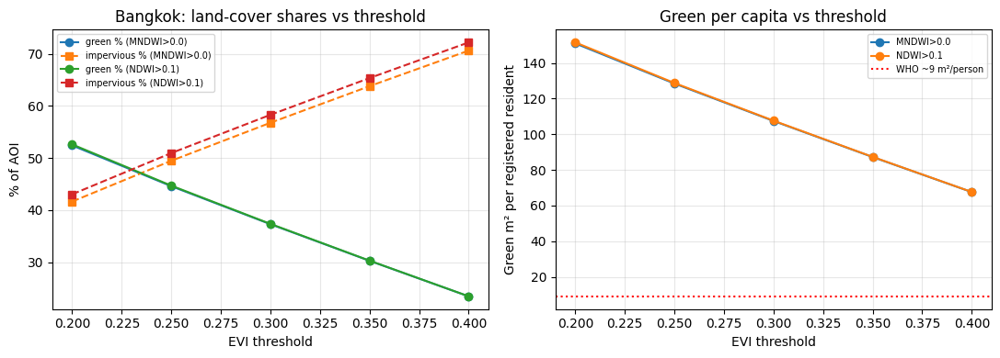

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for wd, d in sens.groupby('water_def'):
    ax[0].plot(d.EVI_threshold, d.green_pct, 'o-', label=f'green % ({wd})')
    ax[0].plot(d.EVI_threshold, d.imperv_pct, 's--', label=f'impervious % ({wd})')
    ax[1].plot(d.EVI_threshold, d.green_m2_per_capita, 'o-', label=wd)
ax[0].set_xlabel('EVI threshold'); ax[0].set_ylabel('% of AOI'); ax[0].legend(fontsize=7); ax[0].grid(alpha=.3)
ax[1].axhline(WHO_M2_PER_CAPITA, color='r', ls=':', label='WHO ~9 m²/person')
ax[1].set_xlabel('EVI threshold'); ax[1].set_ylabel('Green m² per registered resident'); ax[1].legend(fontsize=7); ax[1].grid(alpha=.3)
ax[0].set_title('Bangkok: land-cover shares vs threshold'); ax[1].set_title('Green per capita vs threshold')
plt.tight_layout(); plt.savefig('fig_sensitivity.png', dpi=160); plt.show()

| EVI threshold | % เขียว | % ดาดแข็ง | เขียวต่อหัว (ตร.ม./คน) |
|---|---|---|---|
| 0.2 | 52.6 | 43.1 | 151.6 |
| 0.3 | 37.4 | 58.3 | 107.7 |
| 0.4 | 23.5 | 72.2 | 67.6 |

*ตารางด้านบนถูกพิมพ์ออกมาเป็น Markdown แล้วใน output ของเซลล์ — คัดลอกมาวางแทนได้ทันที*

---
# 7) จุดตรวจ — ตรวจด้วยตาก่อนเชื่อ (Bangkok edition)

แทนตารางจุดตรวจขอนแก่นของคาบ ใช้จุดที่รู้จักในกรุงเทพฯ และให้โค้ด **อ่านคลาสที่จุดนั้นออกมาเลย** (ยังต้องซูมดูด้วยตาควบคู่ — พิกัดเป็นค่าประมาณ)

In [ ]:

# ---- 7) Point checks ----
# Coordinates are approximate, so a single 10 m pixel can land on a pond, a lawn or a runway.
# We therefore report BOTH the pixel class and the class shares inside a 150 m buffer.
checks = [
    ('Lumphini Park (lawn/trees)',            100.5416, 13.7310, 'green'),
    ('Benjakitti Park (forest + large lake)', 100.5590, 13.7290, 'green or water'),
    ('Siam / Rama I road (Pathum Wan)',       100.5340, 13.7462, 'impervious'),
    ('Don Mueang airport (runways + grass)',  100.6068, 13.9126, 'impervious (grass infield may be green)'),
    ('Chao Phraya river near Rama VIII',      100.4990, 13.7710, 'water'),
    ('Nong Chok farmland (dry season)',       100.8700, 13.8800, 'often impervious (fallow paddy)'),
]
pts_fc = ee.FeatureCollection([ee.Feature(ee.Geometry.Point([x, y]), {'name': n}) for n, x, y, _ in checks])
samp = s2i.select(['EVI', 'NDWI', 'MNDWI']).addBands(cls.unmask(0)).sampleRegions(pts_fc, scale=10).getInfo()
names = {0: 'no data', 1: 'green', 2: 'impervious', 3: 'water'}
pc = pd.DataFrame([f['properties'] for f in samp['features']])
pc['pixel_class'] = pc.cls.map(names)

buf_fc = ee.FeatureCollection([ee.Feature(ee.Geometry.Point([x, y]).buffer(150), {'name': n}) for n, x, y, _ in checks])
shares_img = ee.Image.cat([cls.eq(k).unmask(0).rename(v) for k, v in [(1, 'green'), (2, 'impervious'), (3, 'water')]])
sh = pd.DataFrame([f['properties'] for f in shares_img.reduceRegions(buf_fc, ee.Reducer.mean(), scale=10).getInfo()['features']])
sh[['green', 'impervious', 'water']] = (sh[['green', 'impervious', 'water']] * 100).round(0)
sh['buffer_majority'] = sh[['green', 'impervious', 'water']].idxmax(axis=1)
pc = pc.merge(sh.rename(columns={'green': 'green_%150m', 'impervious': 'imperv_%150m', 'water': 'water_%150m'}), on='name')
pc['expected'] = pc.name.map({n: e for n, _, _, e in checks})
display(pc[['name', 'EVI', 'NDWI', 'pixel_class', 'green_%150m', 'imperv_%150m', 'water_%150m', 'buffer_majority', 'expected']].round(3))
RESULTS['point_checks'] = pc.to_dict(orient='records')
for n, x, y, _ in checks:
    Map.addLayer(ee.Geometry.Point([x, y]), {'color': 'yellow'}, n, True)


,name,EVI,NDWI,pixel_class,green_%150m,imperv_%150m,water_%150m,buffer_majority,expected
0,Lumphini Park (lawn/trees),0.288,-0.536,impervious,62.0,31.0,7.0,green,green
1,Benjakitti Park (forest + large lake),-0.068,0.715,water,7.0,26.0,67.0,water,green or water
2,Siam / Rama I road (Pathum Wan),-0.010,-0.020,impervious,11.0,88.0,1.0,impervious,impervious
3,Don Mueang airport (runways + grass),0.471,-0.601,green,67.0,33.0,0.0,green,impervious (grass infield may be green)
4,Chao Phraya river near Rama VIII,-0.133,0.698,water,7.0,11.0,82.0,water,water
5,Nong Chok farmland (dry season),0.308,-0.506,green,63.0,37.0,0.0,green,often impervious (fallow paddy)



| จุดตรวจ | ควรเป็นสี | ถ้าไม่ใช่แปลว่า |
|---|---|---|
| สวนลุมพินี / สวนเบญจกิติ | เขียว (เบญจกิติมีบึงใหญ่ → อาจเป็นฟ้า) | เกณฑ์ EVI สูงไป |
| ถนนพระราม 1 / สนามบินดอนเมือง | แดง (สนามหญ้าระหว่างรันเวย์เป็นเขียวได้) | — |
| แม่น้ำเจ้าพระยา | ฟ้า ไม่ใช่แดง | น้ำขุ่นมาก → NDWI ต่ำ ลอง MNDWI |
| **ที่นาหนองจอก (หน้าแล้ง)** | **มักเป็นแดง!** | นาหลังเก็บเกี่ยว = ดินเปิด → ถูกนับเป็น "ดาดแข็ง" — จุดอ่อนหลักของวิธี |

**ผลจุดตรวจรอบที่รันแล้ว (pixel เดียว, EVI ≥ 0.3):**
- **สวนลุมพินี** EVI = 0.288 → ถูกจัดเป็น *ดาดแข็ง* เพราะต่ำกว่าเกณฑ์เพียง 0.012 — สนามหญ้าหน้าแล้งมี EVI ต่ำ นี่คือหลักฐานตรงที่สุดว่าเกณฑ์ 0.3 ตัดพื้นที่สีเขียวจริงทิ้งได้
- **สวนเบญจกิติ** จุดตกลงบนบึง (NDWI = 0.72) → *น้ำ* ถูกต้องสำหรับพิกเซลนั้น แต่ไม่ได้ทดสอบส่วนป่า — ป้ายคาดหวังเดิมผิด จึงเพิ่มการดูสัดส่วนในรัศมี 150 ม.
- **ดอนเมือง** จุดตกบนสนามหญ้าระหว่างรันเวย์ (EVI = 0.47) → *เขียว* ถูกต้องสำหรับพิกเซลนั้น
- **ถนนพระราม 1** → ดาดแข็ง ✓ · **เจ้าพระยา** → น้ำ ✓ · **นาหนองจอก** EVI = 0.31 → เขียว (เฉียดเกณฑ์ — ในปีที่แล้งกว่าหรือหลังเก็บเกี่ยวจะกลายเป็นดาดแข็ง)

สรุป: พิกัดโดยประมาณ + พิกเซลเดียว ตรวจไม่ได้จริง เซลล์ด้านบนจึงรายงานสัดส่วนคลาสในรัศมี 150 ม. ด้วย — **ยังต้องซูมดูภาพ HYBRID ประกอบทุกจุด**


---
# 8) ข้อมูลเขต 50 เขต + ประชากรรายเขต (รันได้โดยไม่ต้องใช้ GEE)

- **ขอบเขตเขต:** `districts.geojson` จาก OpenGISData-Thailand (chingchai, GitHub) — กรองรหัสจังหวัด `10`
- **ประชากรรายเขต:** ตาราง *List of districts of Bangkok* (Wikipedia, ตัวเลขทะเบียนราษฎร์ของกรมการปกครอง) รวมได้ 5,671,070 คน
  ซึ่งใกล้กับยอดทะเบียนราษฎร์ กทม. ปี 2560 (5,682,415 คน, CEIC/DOPA) → **ตัวเลขรายเขตเป็นข้อมูลราวปี 2560–2561 ไม่ใช่ปีปัจจุบัน**
  ใช้เปรียบเทียบ "ระหว่างเขต" ได้ แต่ค่าสัมบูรณ์ต้องระบุปีกำกับ

In [ ]:
import os, subprocess, requests, geopandas as gpd, shapely

WORKDIR = '/content' if os.path.exists('/content') else os.getcwd()
DIST_URL = 'https://raw.githubusercontent.com/chingchai/OpenGISData-Thailand/master/districts.geojson'
dist_path = os.path.join(WORKDIR, 'th_districts.geojson')
if not os.path.exists(dist_path):
    with open(dist_path, 'wb') as f:
        f.write(requests.get(DIST_URL, timeout=120).content)
districts = gpd.read_file(dist_path)
districts = districts[districts.pro_code == '10'].reset_index(drop=True)      # Bangkok = 10

# Registered population by district — Wikipedia "List of districts of Bangkok" (DOPA figures, ~2017/18 vintage)
POP_DISTRICT = {'Bang Bon':105161,'Bang Kapi':148465,'Bang Khae':191781,'Bang Khen':189539,'Bang Kho Laem':94956,
 'Bang Khun Thian':165491,'Bang Na':95912,'Bang Phlat':99273,'Bang Rak':45875,'Bang Sue':132234,'Bangkok Noi':117793,
 'Bangkok Yai':72321,'Bueng Kum':145830,'Chatuchak':160906,'Chom Thong':158005,'Din Daeng':130220,'Don Mueang':166261,
 'Dusit':107655,'Huai Khwang':78175,'Khan Na Yao':88678,'Khlong Sam Wa':169489,'Khlong San':76446,'Khlong Toei':109041,
 'Lak Si':109770,'Lat Krabang':163175,'Lat Phrao':122182,'Min Buri':137251,'Nong Chok':157138,'Nong Khaem':150218,
 'Pathum Wan':53263,'Phasi Charoen':129827,'Phaya Thai':72952,'Phra Khanong':93482,'Phra Nakhon':57876,
 'Pom Prap Sattru Phai':51006,'Prawet':160671,'Rat Burana':86695,'Ratchathewi':73035,'Sai Mai':188123,
 'Samphanthawong':27452,'Saphan Sung':89825,'Sathon':84916,'Suan Luang':115658,'Taling Chan':106604,
 'Thawi Watthana':76351,'Thon Buri':119708,'Thung Khru':116473,'Wang Thonglang':114768,'Watthana':81623,'Yan Nawa':81521}
districts['pop'] = districts.amp_en.map(POP_DISTRICT)
assert districts['pop'].notna().all() and len(districts) == 50

UTM = 'EPSG:32647'
d_utm = districts.to_crs(UTM)
districts['area_km2'] = d_utm.area / 1e6
core = gpd.GeoSeries([shapely.Point(100.5018, 13.7567)], crs=4326).to_crs(UTM).iloc[0]   # Democracy Monument
districts['dist_core_km'] = d_utm.geometry.centroid.distance(core) / 1000
districts['ring'] = pd.cut(districts.dist_core_km, [0, 8, 16, 100],
                           labels=['Inner (<8 km)', 'Middle (8-16 km)', 'Outer (>16 km)'])
print(f"{len(districts)} districts | area {districts.area_km2.sum():,.1f} km² | registered pop {districts['pop'].sum():,}")
print(districts.groupby('ring', observed=True).agg(n=('amp_en', 'size'), area_km2=('area_km2', 'sum'), pop=('pop', 'sum')))

50 districts | area 1,566.5 km² | registered pop 5,671,070
                   n    area_km2      pop
ring                                     
Inner (<8 km)     19  185.254696  1653412
Middle (8-16 km)  17  398.673118  1940808
Outer (>16 km)    14  982.600983  2076850


---
# 9) อาคารจาก GlobalBuildingAtlas (GBA LoD1) — ขอบล่างของพื้นผิวดาดแข็ง

ไฟล์ `gba_bangkok.parquet` มาจาก notebook `GBA_Bangkok_Colab` (clip ด้วย `ST_PointOnSurface` ในเขต กทม. — 2,192,944 อาคาร)
อาคารเป็น **ส่วนหนึ่ง** ของพื้นผิวดาดแข็ง (ยังขาดถนน ลานจอด ลานคอนกรีต) → สัดส่วนพื้นที่หลังคา (Building Coverage Ratio, BCR) คือ **ขอบล่าง (lower bound)** ของ % ดาดแข็ง
ใช้เป็นข้อมูลอิสระที่ไม่ได้มาจาก Sentinel-2 แบบเดียวกับ EVI (ข้อมูล Google/Microsoft/OSM footprints) สำหรับตรวจสอบข้อ 5

**วิธีคำนวณ:** อ่าน parquet ทีละ row group (ประหยัดหน่วยความจำ) → แปลง WKB → ฉายเป็น UTM 47N (EPSG:32647) → พื้นที่ footprint, centroid, ปริมาตร (พื้นที่ × ความสูง)

In [ ]:
import pyarrow.parquet as pq, time
from pyproj import Transformer

import glob
# Look for the file (also catches Colab's renamed duplicates such as "gba_bangkok (1).parquet")
GBA_PATTERNS = ['/content/gba_bangkok*.parquet', '/content/*/gba_bangkok*.parquet',
                '/content/drive/MyDrive/gba_bangkok*.parquet', '/content/drive/MyDrive/*/gba_bangkok*.parquet',
                '/mnt/user-data/uploads/gba_bangkok*.parquet', './gba_bangkok*.parquet']
def find_gba():
    for pat in GBA_PATTERNS:
        hits = sorted(glob.glob(pat), key=os.path.getsize, reverse=True)   # largest = complete file
        if hits:
            return hits[0]
    return None

GBA_PATH = find_gba()
IN_COLAB = os.path.exists('/content')
if GBA_PATH is None and IN_COLAB:                       # 1) try Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    GBA_PATH = find_gba()
if GBA_PATH is None and IN_COLAB:                       # 2) fall back to a browser upload (~220 MB, takes a few minutes)
    from google.colab import files
    print('gba_bangkok.parquet not found in /content or Drive — choose the file to upload')
    files.upload()
    GBA_PATH = find_gba()
assert GBA_PATH, ('gba_bangkok.parquet not found. Options: upload it to /content, put it in Drive '
                  '(MyDrive/ or MyDrive/<folder>/), or run GBA_Bangkok_Colab in this same runtime first.')
print('GBA file:', GBA_PATH, f'{os.path.getsize(GBA_PATH)/1e6:.0f} MB')

_tr = Transformer.from_crs('EPSG:4326', UTM, always_xy=True)
def _to_utm(xy):
    x, y = _tr.transform(xy[:, 0], xy[:, 1]); return np.column_stack([x, y])

pf, parts, t0 = pq.ParquetFile(GBA_PATH), [], time.time()
for rg in range(pf.num_row_groups):
    t = pf.read_row_group(rg, columns=['source', 'height', 'geometry'])
    geom_utm = shapely.transform(shapely.from_wkb(t.column('geometry').to_numpy(zero_copy_only=False)), _to_utm)
    c = shapely.centroid(geom_utm)
    parts.append(pd.DataFrame({'source': t.column('source').to_numpy(zero_copy_only=False),
                               'height': t.column('height').to_numpy(),
                               'area_m2': shapely.area(geom_utm),
                               'cx': shapely.get_x(c), 'cy': shapely.get_y(c)}))
bld = pd.concat(parts, ignore_index=True); del parts
bld['vol_m3'] = bld.area_m2 * bld.height
print(f'{len(bld):,} buildings processed in {time.time()-t0:.0f} s')

A_BKK = districts.area_km2.sum()
gba_tot = {'n_buildings': int(len(bld)), 'footprint_km2': bld.area_m2.sum() / 1e6,
           'bcr_pct': bld.area_m2.sum() / 1e6 / A_BKK * 100,
           'mean_height_m': bld.height.mean(), 'area_weighted_height_m': bld.vol_m3.sum() / bld.area_m2.sum(),
           'volume_km3': bld.vol_m3.sum() / 1e9, 'median_footprint_m2': bld.area_m2.median(),
           'n_height_lt_1m': int((bld.height < 1).sum())}
by_src = (bld.groupby('source').agg(n=('height', 'size'), footprint_km2=('area_m2', lambda s: s.sum() / 1e6),
                                    mean_height_m=('height', 'mean'), median_footprint_m2=('area_m2', 'median'))
          .sort_values('n', ascending=False))
by_src['pct_count'] = by_src.n / by_src.n.sum() * 100
by_src['pct_footprint'] = by_src.footprint_km2 / by_src.footprint_km2.sum() * 100
print(json.dumps({k: round(v, 3) if isinstance(v, float) else v for k, v in gba_tot.items()}, indent=1))
display(by_src.round(2))
RESULTS['gba_totals'] = gba_tot; RESULTS['gba_by_source'] = by_src.reset_index().to_dict(orient='records')

Mounted at /content/drive
GBA file: /content/drive/MyDrive/GE43617 9 2569/gba_bangkok.parquet 220 MB
2,192,944 buildings processed in 16 s
{
 "n_buildings": 2192944,
 "footprint_km2": 326.12,
 "bcr_pct": 20.818,
 "mean_height_m": 5.22,
 "area_weighted_height_m": 7.247,
 "volume_km3": 2.364,
 "median_footprint_m2": 85.611,
 "n_height_lt_1m": 53446
}


,n,footprint_km2,mean_height_m,median_footprint_m2,pct_count,pct_footprint
source,,,,,,
google,1921281,240.25,5.01,78.32,87.61,73.67
ms,138958,31.83,5.87,136.83,6.34,9.76
osm,126271,48.66,7.56,136.60,5.76,14.92
ours2,6434,5.38,7.00,378.60,0.29,1.65


In [ ]:
# ---- building statistics per district and per ring ----
tree = shapely.STRtree(d_utm.geometry.values)
pi, di = tree.query(shapely.points(bld.cx.values, bld.cy.values), predicate='within')
bld['district'] = None
bld.loc[pi, 'district'] = districts.amp_en.values[di]
print(f"buildings whose centroid falls outside the 50 district polygons: {bld.district.isna().sum():,} "
      f"({bld.district.isna().mean()*100:.2f}%) — boundary mismatch between geoBoundaries (clip) and OpenGISData (districts)")

agg = bld.groupby('district').agg(n=('height', 'size'), foot_m2=('area_m2', 'sum'), vol_m3=('vol_m3', 'sum'), mean_h=('height', 'mean'))
D = districts.merge(agg, left_on='amp_en', right_index=True, how='left')
D['bcr_pct']        = D.foot_m2 / (D.area_km2 * 1e6) * 100
D['far_proxy']      = D.vol_m3 / 3.0 / (D.area_km2 * 1e6)          # floors ≈ height / 3 m → floor-area ratio proxy
D['density_km2']    = D['pop'] / D.area_km2
D['nonbuilt_m2_pc'] = (D.area_km2 * 1e6 - D.foot_m2) / D['pop']      # upper bound of open land (roads+green+water) per person

Rg = D.groupby('ring', observed=True).agg(n_districts=('amp_en', 'size'), area_km2=('area_km2', 'sum'), pop=('pop', 'sum'),
                                          foot_m2=('foot_m2', 'sum'), vol_m3=('vol_m3', 'sum'))
Rg['bcr_pct'] = Rg.foot_m2 / (Rg.area_km2 * 1e6) * 100
Rg['density_km2'] = Rg['pop'] / Rg.area_km2
Rg['nonbuilt_m2_pc'] = (Rg.area_km2 * 1e6 - Rg.foot_m2) / Rg['pop']
Rg['weighted_height_m'] = Rg.vol_m3 / Rg.foot_m2
display(Rg.drop(columns=['foot_m2', 'vol_m3']).round(1))

cols = ['amp_en', 'amp_th', 'ring', 'area_km2', 'pop', 'density_km2', 'n', 'bcr_pct', 'mean_h', 'far_proxy', 'nonbuilt_m2_pc', 'dist_core_km']
D[cols].sort_values('bcr_pct', ascending=False).to_csv('lab4_gba_district_stats.csv', index=False)
display(D[cols].sort_values('bcr_pct', ascending=False).head(8).round(1))
display(D[cols].sort_values('bcr_pct', ascending=False).tail(8).round(1))
from scipy import stats
r_bcr = stats.pearsonr(D.dist_core_km, D.bcr_pct)
print(f'Pearson r (BCR vs distance to core) = {r_bcr[0]:.3f}, p = {r_bcr[1]:.1e}, n = 50')
RESULTS['gba_rings'] = Rg.drop(columns=['foot_m2', 'vol_m3']).reset_index().astype({'ring': str}).to_dict(orient='records')
RESULTS['gba_bcr_vs_distance_r'] = float(r_bcr[0])
RESULTS['gba_districts'] = D[cols].astype({'ring': str}).to_dict(orient='records')

buildings whose centroid falls outside the 50 district polygons: 19,778 (0.90%) — boundary mismatch between geoBoundaries (clip) and OpenGISData (districts)


,n_districts,area_km2,pop,bcr_pct,density_km2,nonbuilt_m2_pc,weighted_height_m
ring,,,,,,,
Inner (<8 km),19,185.3,1653412,33.9,8925.1,74.1,9.4
Middle (8-16 km),17,398.7,1940808,27.1,4868.2,149.7,8.1
Outer (>16 km),14,982.6,2076850,15.5,2113.6,399.7,5.7


,amp_en,amp_th,ring,area_km2,pop,density_km2,n,bcr_pct,mean_h,far_proxy,nonbuilt_m2_pc,dist_core_km
48,Pom Prap Sattru Phai,ป้อมปราบศัตรูพ่าย,Inner (<8 km),2.5,51006,20442.3,5910,46.4,7.4,1.5,26.2,1.2
34,Bang Rak,บางรัก,Inner (<8 km),4.0,45875,11512.5,6698,45.2,10.9,2.9,47.6,4.1
15,Din Daeng,ดินแดง,Inner (<8 km),9.3,130220,13946.3,25468,42.2,6.0,1.2,41.4,6.9
41,Khlong San,คลองสาน,Inner (<8 km),5.5,76446,13830.2,18069,41.0,6.4,1.2,42.7,3.7
44,Samphanthawong,สัมพันธวงศ์,Inner (<8 km),1.4,27452,19799.7,2872,40.8,6.9,1.1,29.9,2.1
43,Bangkok Yai,บางกอกใหญ่,Inner (<8 km),6.0,72321,11955.9,22615,40.7,6.1,0.9,49.6,3.6
42,Thon Buri,ธนบุรี,Inner (<8 km),8.8,119708,13530.9,30252,40.4,6.3,1.0,44.0,4.9
9,Wang Thonglang,วังทองหลาง,Middle (8-16 km),17.5,114768,6556.9,49201,39.5,5.4,0.9,92.3,11.9


,amp_en,amp_th,ring,area_km2,pop,density_km2,n,bcr_pct,mean_h,far_proxy,nonbuilt_m2_pc,dist_core_km
5,Thung Khru,ทุ่งครุ,Middle (8-16 km),33.2,116473,3511.6,58772,22.2,5.6,0.5,221.5,14.2
2,Bang Khae,บางแค,Middle (8-16 km),47.2,191781,4062.5,47855,21.3,5.5,0.5,193.8,12.4
39,Min Buri,มีนบุรี,Outer (>16 km),61.4,137251,2233.8,75753,16.4,3.9,0.3,374.5,28.0
4,Thawi Watthana,ทวีวัฒนา,Middle (8-16 km),52.0,76351,1467.7,66746,15.9,4.6,0.3,572.9,14.6
12,Bang Khun Thian,บางขุนเทียน,Outer (>16 km),126.8,165491,1304.9,105035,13.0,5.2,0.3,666.7,20.2
46,Lat Krabang,ลาดกระบัง,Outer (>16 km),124.9,163175,1306.2,98775,12.8,3.3,0.2,667.4,31.3
6,Khlong Sam Wa,คลองสามวา,Outer (>16 km),115.5,169489,1467.8,111474,12.4,4.0,0.2,597.1,28.7
37,Nong Chok,หนองจอก,Outer (>16 km),234.1,157138,671.3,113591,5.3,3.0,0.1,1410.0,39.9


Pearson r (BCR vs distance to core) = -0.817, p = 4.6e-13, n = 50


In [ ]:
# ---- 500 m / 1 km building-fraction grids (the 1 km grid is re-used in section 13 against EVI/AlphaEarth/GHSL) ----
bkk_union = shapely.union_all(d_utm.geometry.values)
def building_fraction_grid(cell):
    x0, y0, x1, y1 = d_utm.total_bounds
    nx, ny = int((x1 - x0) // cell) + 1, int((y1 - y0) // cell) + 1
    ix = ((bld.cx - x0) // cell).astype(int); iy = ((bld.cy - y0) // cell).astype(int)
    s = bld.assign(ix=ix, iy=iy).groupby(['ix', 'iy']).area_m2.sum()
    arr = np.zeros((ny, nx)); arr[s.index.get_level_values(1), s.index.get_level_values(0)] = s.values / cell**2
    xs = x0 + (np.arange(nx) + 0.5) * cell; ys = y0 + (np.arange(ny) + 0.5) * cell
    XX, YY = np.meshgrid(xs, ys)
    inside = shapely.contains_xy(bkk_union, XX, YY)                  # cell centre inside Bangkok
    return np.clip(arr, 0, 1), inside, (x0, y0, nx, ny)

grids = {c: building_fraction_grid(c) for c in (500, 1000)}
for c, (arr, inside, _) in grids.items():
    v = arr[inside]
    print(f'{c:4d} m cells: {inside.sum():5d} | mean {v.mean():.3f} | median {np.median(v):.3f} | p90 {np.percentile(v, 90):.3f} | '
          f'>0.30: {(v > .3).mean()*100:4.1f}% | <0.05: {(v < .05).mean()*100:4.1f}%')
    RESULTS[f'gba_grid_{c}m'] = {'n_cells': int(inside.sum()), 'mean': float(v.mean()), 'median': float(np.median(v)),
                                 'p90': float(np.percentile(v, 90)), 'share_gt_0.30': float((v > .3).mean()),
                                 'share_lt_0.05': float((v < .05).mean())}

# 1 km grid polygons (cells inside Bangkok) as a GeoDataFrame for GEE
arr, inside, (x0, y0, nx, ny) = grids[1000]
iy, ix = np.where(inside)
grid1k = gpd.GeoDataFrame({'cell_id': np.arange(len(ix)), 'gba_bf': arr[iy, ix]},
                          geometry=shapely.box(x0 + ix * 1000, y0 + iy * 1000, x0 + (ix + 1) * 1000, y0 + (iy + 1) * 1000),
                          crs=UTM)
grid1k.to_file('lab4_gba_grid_1km.geojson', driver='GeoJSON')
print('1 km grid cells for GEE:', len(grid1k))

 500 m cells:  6274 | mean 0.206 | median 0.204 | p90 0.404 | >0.30: 29.5% | <0.05: 21.2%
1000 m cells:  1574 | mean 0.204 | median 0.205 | p90 0.383 | >0.30: 27.6% | <0.05: 18.7%
1 km grid cells for GEE: 1574


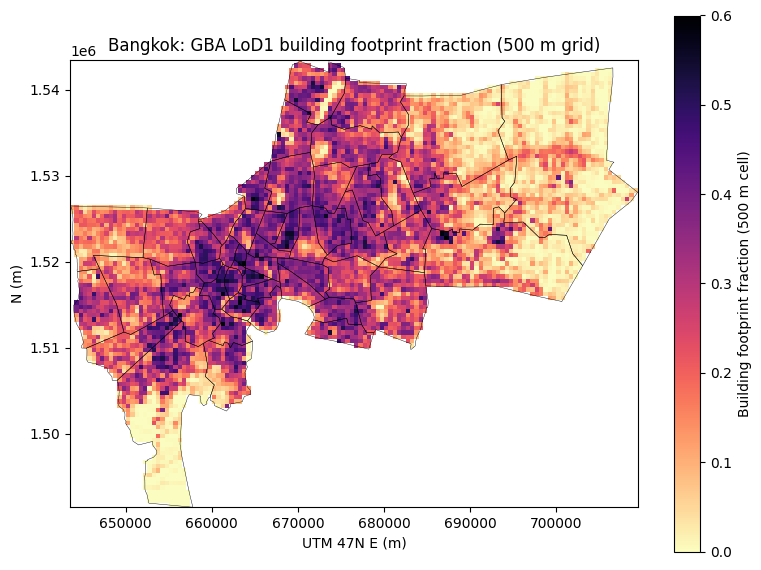

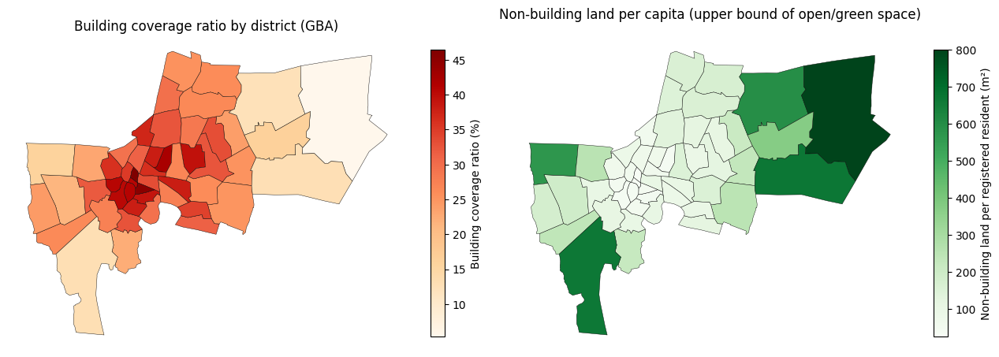

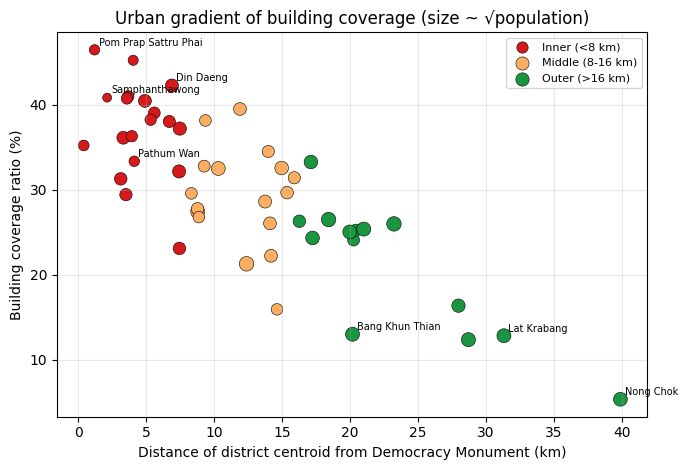

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
arr, inside, (x0, y0, nx, ny) = grids[500]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(np.where(inside, arr, np.nan), origin='lower', extent=[x0, x0 + nx * 500, y0, y0 + ny * 500], cmap='magma_r', vmin=0, vmax=0.6)
d_utm.boundary.plot(ax=ax, color='k', lw=0.3)
plt.colorbar(im, ax=ax, shrink=0.8, label='Building footprint fraction (500 m cell)')
ax.set_title('Bangkok: GBA LoD1 building footprint fraction (500 m grid)'); ax.set_xlabel('UTM 47N E (m)'); ax.set_ylabel('N (m)')
plt.tight_layout(); plt.savefig('fig_gba_bf_500m.png', dpi=160); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))
D.to_crs(UTM).plot(column='bcr_pct', cmap='OrRd', legend=True, ax=axs[0], edgecolor='k', linewidth=0.3,
                   legend_kwds={'label': 'Building coverage ratio (%)', 'shrink': 0.7})
axs[0].set_title('Building coverage ratio by district (GBA)'); axs[0].set_axis_off()
D.to_crs(UTM).plot(column='nonbuilt_m2_pc', cmap='Greens', legend=True, ax=axs[1], edgecolor='k', linewidth=0.3, vmax=800,
                   legend_kwds={'label': 'Non-building land per registered resident (m²)', 'shrink': 0.7})
axs[1].set_title('Non-building land per capita (upper bound of open/green space)'); axs[1].set_axis_off()
plt.tight_layout(); plt.savefig('fig_district_bcr_nonbuilt.png', dpi=160); plt.show()

fig, ax = plt.subplots(figsize=(7, 4.8))
for rname, colr in zip(D.ring.cat.categories, ['#d7191c', '#fdae61', '#1a9641']):
    s = D[D.ring == rname]
    ax.scatter(s.dist_core_km, s.bcr_pct, label=rname, c=colr, s=np.sqrt(s['pop']) / 4, edgecolor='k', lw=0.4)
for _, r in D.iterrows():
    if r.amp_en in ['Pathum Wan', 'Nong Chok', 'Samphanthawong', 'Bang Khun Thian', 'Lat Krabang', 'Pom Prap Sattru Phai', 'Din Daeng']:
        ax.annotate(r.amp_en, (r.dist_core_km, r.bcr_pct), fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Distance of district centroid from Democracy Monument (km)'); ax.set_ylabel('Building coverage ratio (%)')
ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_title('Urban gradient of building coverage (size ~ √population)')
plt.tight_layout(); plt.savefig('fig_bcr_gradient.png', dpi=160); plt.show()

**อ่านผลส่วน 9:** BCR ระดับจังหวัดคือขอบล่างของ % ดาดแข็ง — ถ้าข้อ 5 ได้ % ดาดแข็ง **ต่ำกว่า** BCR ของ GBA แปลว่าวิธี EVI ผิดแน่นอน
ส่วนความต่างระหว่าง % ดาดแข็ง (EVI) กับ BCR คือถนน ลานจอด ลานคอนกรีต **บวก** ดินเปิด/นาหลังเก็บเกี่ยวที่ EVI นับรวมไปด้วย

---
# 10) นิยามพื้นที่สีเขียวแบบอื่น — ตัดนาข้าวออก / เฉพาะเรือนยอดไม้ (ตอบคำถามข้อ 2 เชิงปริมาณ)

ใช้ **ESA WorldCover v200 (2021, 10 ม.)** ซ้อนกับผล EVI:
- **G0 (นิยามของคาบ):** EVI ≥ 0.3
- **G1 เขียวที่ไม่ใช่เกษตร:** G0 และ WorldCover ≠ 40 (cropland) — ตัดนาข้าว/ไร่ออก
- **G2 เรือนยอดไม้:** G0 และ WorldCover = 10 (tree cover) — ใกล้กับ "ร่มเงา" ที่ลดความร้อนได้จริง

> ข้อจำกัด: WorldCover เป็นข้อมูลปี 2021 ส่วน EVI เป็นปี 2026 · ยังไม่ใช่ "พื้นที่ที่ประชาชนเข้าถึงได้" (ต้องใช้ขอบเขตสวนสาธารณะจาก OSM/กทม. + ระยะเดินเท้า)

In [ ]:

wc = ee.ImageCollection('ESA/WorldCover/v200').first().select('Map').clip(aoi_geom)
g0 = cls.eq(1)
# Earth Engine band names allow only letters, digits and '_' — keep labels separately
defs = {'G0_evi': g0, 'G1_noncrop': g0.And(wc.neq(40)), 'G2_tree': g0.And(wc.eq(10))}
DEF_LABEL = {'G0_evi': 'G0: EVI >= 0.3 (class definition)', 'G1_noncrop': 'G1: G0 minus WorldCover cropland',
             'G2_tree': 'G2: G0 within WorldCover tree cover'}
px = ee.Image.pixelArea()
stack = ee.Image.cat([px.updateMask(m).rename(k) for k, m in defs.items()])
a = stack.reduceRegion(ee.Reducer.sum(), aoi_geom, scale=SCALE, maxPixels=1e11, tileScale=4).getInfo()
gdef = pd.DataFrame([{'definition': DEF_LABEL[k], 'green_km2': (a.get(k) or 0) / 1e6,
                      'green_pct': (a.get(k) or 0) / 1e6 / total_km2 * 100,
                      'm2_per_capita_registered': (a.get(k) or 0) / POPULATION,
                      'm2_per_capita_resident': (a.get(k) or 0) / POPULATION_RESIDENT} for k in defs])
display(gdef.round(2))
RESULTS['green_definitions'] = gdef.to_dict(orient='records')

# what are the "green" pixels made of? (WorldCover composition of G0)
wc_names = {10: 'tree', 20: 'shrub', 30: 'grass', 40: 'cropland', 50: 'built-up', 60: 'bare', 80: 'water', 90: 'herb. wetland', 95: 'mangrove'}
hist = px.updateMask(g0).addBands(wc).reduceRegion(ee.Reducer.sum().group(groupField=1, groupName='wc'),
                                                  aoi_geom, scale=SCALE, maxPixels=1e11, tileScale=4).getInfo()['groups']
comp = pd.DataFrame([{'worldcover': wc_names.get(h['wc'], h['wc']), 'km2': h['sum'] / 1e6} for h in hist])
comp['share_of_green_pct'] = comp.km2 / comp.km2.sum() * 100
display(comp.sort_values('km2', ascending=False).round(1))
RESULTS['green_worldcover_composition'] = comp.to_dict(orient='records')


,definition,green_km2,green_pct,m2_per_capita_registered,m2_per_capita_resident
0,G0: EVI >= 0.3 (class definition),587.35,37.37,107.65,55.94
1,G1: G0 minus WorldCover cropland,424.37,27.00,77.78,40.42
2,G2: G0 within WorldCover tree cover,238.42,15.17,43.70,22.71


,worldcover,km2,share_of_green_pct
0,tree,238.4,40.6
3,cropland,163.0,27.7
4,built-up,94.0,16.0
2,grass,82.8,14.1
6,water,4.5,0.8
7,herb. wetland,2.6,0.4
5,bare,1.3,0.2
8,mangrove,0.7,0.1
1,shrub,0.0,0.0


---
# 11) ⭐ ท้าทาย: ตัวชี้วัดรายเขต 50 เขต — ความเหลื่อมล้ำของพื้นที่สีเขียว

โจทย์ท้าทายให้เทียบ 2 อำเภอ (เมือง vs รอบนอก) — ที่นี่ทำครบ 50 เขต แล้วดึง **ปทุมวัน (ชั้นใน)** กับ **หนองจอก (ชั้นนอก)** มาเทียบให้ชัด
ใช้ขอบเขตเขตจากส่วน 8 (ต้องรันส่วน 8 ก่อน) และประชากรรายเขตชุดเดียวกัน

In [ ]:
dist_fc = geemap.gdf_to_ee(districts[['amp_en', 'pop', 'area_km2', 'geometry']].assign(geometry=districts.geometry.simplify(0.0001)))
fr = ee.Image.cat([cls.eq(1).unmask(0).rename('green'), cls.eq(2).unmask(0).rename('imperv'),
                   cls.eq(3).unmask(0).rename('water'), defs['G1_noncrop'].unmask(0).rename('green_noncrop'),
                   defs['G2_tree'].unmask(0).rename('tree')])
red = fr.reduceRegions(dist_fc, ee.Reducer.mean(), scale=20, tileScale=4).getInfo()
DG = pd.DataFrame([f['properties'] for f in red['features']])
for b in ['green', 'imperv', 'water', 'green_noncrop', 'tree']:
    DG[f'{b}_pct'] = DG[b] * 100
    DG[f'{b}_m2_pc'] = DG[b] * DG.area_km2 * 1e6 / DG['pop']
DG = DG.merge(districts[['amp_en', 'amp_th', 'ring', 'dist_core_km']], on='amp_en')
if 'D' in globals():   # add GBA building coverage from section 9
    DG = DG.merge(D[['amp_en', 'bcr_pct', 'density_km2']], on='amp_en')
DG.to_csv('lab4_district_green_imperv.csv', index=False)
show = ['amp_en', 'ring', 'green_pct', 'imperv_pct', 'green_m2_pc', 'green_noncrop_m2_pc', 'tree_m2_pc'] + (['bcr_pct'] if 'bcr_pct' in DG else [])
display(DG.sort_values('green_m2_pc')[show].round(1))

print('\nPathum Wan vs Nong Chok:')
display(DG[DG.amp_en.isin(['Pathum Wan', 'Nong Chok'])][show].round(1))

ring_tab = DG.assign(green_km2=DG.green * DG.area_km2, tree_km2=DG.tree * DG.area_km2).groupby('ring', observed=True).agg(
    area_km2=('area_km2', 'sum'), pop=('pop', 'sum'), green_km2=('green_km2', 'sum'), tree_km2=('tree_km2', 'sum'))
ring_tab['green_m2_pc'] = ring_tab.green_km2 * 1e6 / ring_tab['pop']
ring_tab['tree_m2_pc'] = ring_tab.tree_km2 * 1e6 / ring_tab['pop']
display(ring_tab.round(1))
n_below = int((DG.tree_m2_pc < WHO_M2_PER_CAPITA).sum())
print(f'districts with tree-canopy green < {WHO_M2_PER_CAPITA} m²/person: {n_below} / 50')

# Inequality of green per capita across people: Gini over districts, population-weighted
def gini_weighted(x, w):
    o = np.argsort(x); x, w = np.asarray(x)[o], np.asarray(w)[o]
    cw = np.cumsum(w) / w.sum(); cx = np.cumsum(x * w) / (x * w).sum()
    return 1 - np.sum((cx[1:] + cx[:-1]) * np.diff(cw)) - cx[0] * cw[0]
RESULTS['district_gini_green_pc'] = float(gini_weighted(DG.green_m2_pc, DG['pop']))
RESULTS['district_gini_tree_pc'] = float(gini_weighted(DG.tree_m2_pc, DG['pop']))
RESULTS['district_ring_green'] = ring_tab.reset_index().astype({'ring': str}).to_dict(orient='records')
RESULTS['districts_green'] = DG[show].astype({'ring': str}).to_dict(orient='records')
RESULTS['n_districts_tree_below_WHO'] = n_below
print('population-weighted Gini of green m²/person across districts:', round(RESULTS['district_gini_green_pc'], 3),
      '| tree canopy:', round(RESULTS['district_gini_tree_pc'], 3))

,amp_en,ring,green_pct,imperv_pct,green_m2_pc,green_noncrop_m2_pc,tree_m2_pc,bcr_pct
44,Samphanthawong,Inner (<8 km),0.8,86.1,0.4,0.4,0.1,40.8
48,Pom Prap Sattru Phai,Inner (<8 km),3.3,96.5,1.6,1.6,0.7,46.4
34,Bang Rak,Inner (<8 km),4.9,90.4,4.3,4.3,1.8,45.2
15,Din Daeng,Inner (<8 km),6.8,93.1,4.9,4.8,1.6,42.2
38,Phra Nakhon,Inner (<8 km),6.8,86.3,6.2,6.2,2.1,35.2
41,Khlong San,Inner (<8 km),8.9,84.0,6.4,6.4,3.2,41.0
42,Thon Buri,Inner (<8 km),9.7,83.9,7.2,7.1,3.0,40.4
22,Bang Kho Laem,Inner (<8 km),10.3,79.6,9.0,8.9,4.4,38.0
13,Sathon,Inner (<8 km),11.4,86.2,9.6,9.6,4.9,39.0
14,Bang Sue,Inner (<8 km),12.5,84.0,11.9,8.7,4.4,37.2



Pathum Wan vs Nong Chok:


,amp_en,ring,green_pct,imperv_pct,green_m2_pc,green_noncrop_m2_pc,tree_m2_pc,bcr_pct
33,Pathum Wan,Inner (<8 km),19.8,78.7,29.8,29.7,17.5,33.3
37,Nong Chok,Outer (>16 km),70.5,28.3,1050.7,467.7,285.2,5.3


,area_km2,pop,green_km2,tree_km2,green_m2_pc,tree_m2_pc
ring,,,,,,
Inner (<8 km),185.3,1653412,34.8,20.0,21.0,12.1
Middle (8-16 km),398.7,1940808,98.7,51.2,50.8,26.4
Outer (>16 km),982.6,2076850,439.7,154.9,211.7,74.6


districts with tree-canopy green < 9.0 m²/person: 16 / 50
population-weighted Gini of green m²/person across districts: 0.636 | tree canopy: 0.565


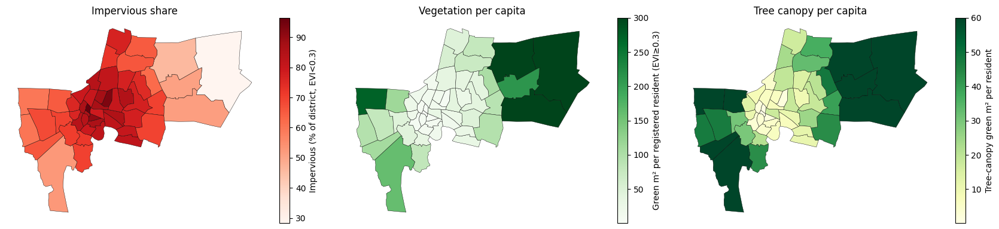

In [ ]:
gd = districts[['amp_en', 'geometry']].merge(DG, on='amp_en').to_crs(UTM)
fig, axs = plt.subplots(1, 3, figsize=(17, 5.2))
for ax, col, cmap, lab, vmax in [(axs[0], 'imperv_pct', 'Reds', 'Impervious (% of district, EVI<0.3)', None),
                                 (axs[1], 'green_m2_pc', 'Greens', 'Green m² per registered resident (EVI≥0.3)', 300),
                                 (axs[2], 'tree_m2_pc', 'YlGn', 'Tree-canopy green m² per resident', 60)]:
    gd.plot(column=col, cmap=cmap, legend=True, ax=ax, edgecolor='k', linewidth=0.3, vmax=vmax, legend_kwds={'label': lab, 'shrink': 0.7})
    ax.set_axis_off()
axs[0].set_title('Impervious share'); axs[1].set_title('Vegetation per capita'); axs[2].set_title('Tree canopy per capita')
plt.tight_layout(); plt.savefig('fig_district_green_imperv.png', dpi=160); plt.show()

---
# 12) เทียบกับ Dynamic World + วิธี AlphaEarth Random Forest (Moukomla et al., 2026)

บทความของผู้สอนเสนอว่า **AlphaEarth embeddings (64 มิติ, รายปี) + Random Forest** ทำแผนที่ดาดแข็งในเขตร้อนได้ดีกว่าวิธีดัชนีมาก
(กรุงเทพฯ: AlphaEarth IoU ≈ 0.886 เทียบ NDVI<0.2 = 0.462 เทียบกับ Dynamic World) — ส่วนนี้ทดสอบซ้ำในกรุงเทพฯ ด้วยโปรโตคอลเดียวกันแบบย่อ:

| องค์ประกอบ | บทความ | ที่นี่ |
|---|---|---|
| ป้ายกำกับ | Dynamic World `built` > 0.5 | เหมือนกัน (ค่าเฉลี่ยทั้งปี) |
| RF | 100 ต้น, max_depth 15, min_leaf 5, seed 42 | 100 ต้น, `minLeafPopulation=5`, seed 42 (GEE ไม่มี `max_depth` — ใช้ค่าปริยาย) |
| แบ่งข้อมูล | 70/30 stratified | 70/30 (สุ่มด้วย `randomColumn`, seed 42) บน stratified sample 1,000 จุด/คลาส |
| พื้นที่ | กรอบ 60×60 กม. | ขอบเขต GAUL ของ กทม. |

⚠️ ทุกค่า IoU ที่นี่คือ **ความสอดคล้องกับ Dynamic World** ไม่ใช่ความถูกต้องเทียบความจริงภาคสนาม และ Dynamic World กับ AlphaEarth มาจาก Sentinel-2 เหมือนกัน (shared lineage)

In [ ]:
AE = ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
ae_years = sorted(set(AE.filterBounds(aoi_geom).aggregate_array('system:time_start')
                      .map(lambda t: ee.Date(t).get('year')).getInfo()))
print('AlphaEarth years available over Bangkok:', ae_years)
AE_YEAR = 2024 if 2024 in ae_years else ae_years[-1]      # 2024 = last year used in the paper
BANDS = [f'A{i:02d}' for i in range(64)]

region_lst = aoi_geom.buffer(10000)                        # Bangkok + 10 km (needed later for rural LST reference)
emb = AE.filterDate(f'{AE_YEAR}-01-01', f'{AE_YEAR + 1}-01-01').filterBounds(region_lst).mosaic().select(BANDS)
dw_built = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1').filterBounds(region_lst)
            .filterDate(f'{AE_YEAR}-01-01', f'{AE_YEAR + 1}-01-01').select('built').mean())
label = dw_built.gt(0.5).rename('label')

pts = (emb.addBands(label).stratifiedSample(numPoints=1000, classBand='label', region=aoi_geom, scale=10,
                                            seed=42, geometries=True, tileScale=4)
       .randomColumn('rand', 42))
train, test = pts.filter(ee.Filter.lt('rand', 0.7)), pts.filter(ee.Filter.gte('rand', 0.7))
rf = ee.Classifier.smileRandomForest(numberOfTrees=100, minLeafPopulation=5, seed=42).train(train, 'label', BANDS)
isa_ae = emb.classify(rf).rename('isa_ae')

def scores(y, p):
    y, p = np.asarray(y).astype(int), np.asarray(p).astype(int)
    tp, fp, fn, tn = ((y == 1) & (p == 1)).sum(), ((y == 0) & (p == 1)).sum(), ((y == 1) & (p == 0)).sum(), ((y == 0) & (p == 0)).sum()
    return {'IoU': tp / (tp + fp + fn), 'F1': 2 * tp / (2 * tp + fp + fn), 'OA': (tp + tn) / len(y), 'n': int(len(y))}

# --- comparison methods for the SAME year, evaluated on the SAME held-out points
s2Y, _   = make_s2(f'{AE_YEAR}-01-01', f'{AE_YEAR}-04-30', region=region_lst)          # dry-season composite
s2Yi     = add_indices(s2Y)
evi_imp  = classify(s2Yi, 0.3, 'NDWI', 0.1, region=region_lst).eq(2).rename('evi_imp')   # class method (3-class)
s2Ann, _ = make_s2(f'{AE_YEAR}-01-01', f'{AE_YEAR}-12-31', region=region_lst, max_cloud=80)
ndvi_imp = s2Ann.normalizedDifference(['B8', 'B4']).lt(0.2).rename('ndvi_imp')           # paper Method 4

tp_img = ee.Image.cat([isa_ae, evi_imp, ndvi_imp])
te = pd.DataFrame([f['properties'] for f in tp_img.sampleRegions(test, properties=['label'], scale=10).getInfo()['features']])
acc = pd.DataFrame({m: scores(te.label, te[c]) for m, c in
                    [('AlphaEarth RF (64-D)', 'isa_ae'), ('EVI<0.3 (class method)', 'evi_imp'), ('NDVI<0.2 annual median', 'ndvi_imp')]}).T
display(acc.round(3))
RESULTS['agreement_vs_dynamic_world'] = {'year': AE_YEAR, **acc.round(4).to_dict(orient='index')}

AlphaEarth years available over Bangkok: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,IoU,F1,OA,n
AlphaEarth RF (64-D),0.884,0.938,0.935,598.0
EVI<0.3 (class method),0.612,0.759,0.742,598.0
NDVI<0.2 annual median,0.422,0.593,0.654,598.0


In [ ]:
# --- wall-to-wall impervious share of Bangkok by method (same year), 30 m for tractability
AREA_SCALE = 30
imp_stack = ee.Image.cat([isa_ae, evi_imp.unmask(0), ndvi_imp.unmask(0), label.rename('dw_built')]).clip(aoi_geom)
share = imp_stack.reduceRegion(ee.Reducer.mean(), aoi_geom, scale=AREA_SCALE, maxPixels=1e10, tileScale=8).getInfo()
share = {k: v * 100 for k, v in share.items()}
print(f'Impervious share of Bangkok ({AE_YEAR}, % of AOI):', {k: round(v, 1) for k, v in share.items()})
if 'gba_tot' in globals():
    print(f"GBA building coverage (lower bound): {gba_tot['bcr_pct']:.1f}%")
RESULTS['imperv_share_by_method'] = {'year': AE_YEAR, 'scale_m': AREA_SCALE, **share}

Map2 = geemap.Map(); Map2.add_basemap('HYBRID')
Map2.addLayer(isa_ae.clip(aoi_geom).selfMask(), {'palette': ['#7b3294']}, f'AlphaEarth RF ISA {AE_YEAR}')
Map2.addLayer(evi_imp.clip(aoi_geom).selfMask(), {'palette': ['#d7191c']}, f'EVI<0.3 impervious {AE_YEAR}', False)
Map2.addLayer(label.clip(aoi_geom).selfMask(), {'palette': ['#fdae61']}, f'Dynamic World built>0.5 {AE_YEAR}', False)
Map2.centerObject(aoi, 11); Map2

Impervious share of Bangkok (2024, % of AOI): {'dw_built': 64.4, 'evi_imp': 59.3, 'isa_ae': 63.4, 'ndvi_imp': 32.7}
GBA building coverage (lower bound): 20.8%


Map(center=[13.771324157733092, 100.62705713902751], controls=(WidgetControl(options=['position', 'transparent…

---
# 13) ความสอดคล้องเชิงพื้นที่ที่ 1 กม. กับข้อมูลอิสระ (GBA อาคาร + JRC GHSL)

แนวเดียวกับ Section 3.10 ของบทความ: เทียบสัดส่วนดาดแข็งของแต่ละวิธีกับ **สัดส่วนหลังคาอาคาร** ในกริด 1 กม. (ข้อมูลอิสระจาก Sentinel-2 composite ของเรา)
- GBA: จากส่วน 9 (Google/Microsoft/OSM footprints)
- GHSL: `JRC/GHSL/P2023A/GHS_BUILT_S` epoch **2020** (m² อาคารต่อเซลล์ 100 ม.) — แปลงเป็นสัดส่วนด้วยการ **หารด้วยพื้นที่พิกเซล**
  (ชุด 100 ม. มีเฉพาะปีละ 5 ปี 1975…2030 — ไม่มีภาพ `/2018` ที่บทความอ้างถึง ซึ่งน่าจะหมายถึงชุด 10 ม. ปี 2018; ที่นี่ใช้ 2020 ที่ใกล้ที่สุด)

คาดหวัง: ดาดแข็ง ≥ หลังคา เสมอ (bias เป็นบวก) · สิ่งที่ควรดูคือ **r (รูปแบบเชิงพื้นที่)** มากกว่าค่าสัมบูรณ์

GHSL layer: GHS_BUILT_S epoch 2020 (100 m)
1 km cells with all layers: 1568


,layer,pearson_r_vs_GBA,mean_layer,mean_GBA,bias_layer_minus_GBA,rmse,share_cells_layer_below_GBA_%
0,evi_imp_2026,0.868,0.599,0.204,0.395,0.415,0.000
1,isa_ae,0.909,0.638,0.204,0.434,0.493,2.997
2,dw_built,0.902,0.647,0.204,0.443,0.493,2.615
3,ghsl_bf,0.956,0.213,0.204,0.009,0.040,42.985


EVI green fraction vs GBA building fraction: r = -0.717 (expected negative)


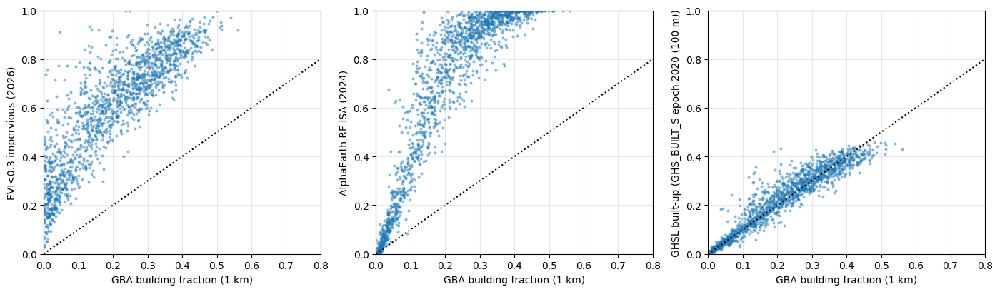

In [ ]:

grid_fc = geemap.gdf_to_ee(grid1k.to_crs(4326)[['cell_id', 'gba_bf', 'geometry']])

def load_ghsl():
    """GHSL built-up surface (m² per cell) -> fraction. The 100 m collection only has 5-year epochs."""
    col = ee.ImageCollection('JRC/GHSL/P2023A/GHS_BUILT_S')
    tries = [('GHS_BUILT_S epoch 2020 (100 m)', lambda: col.filter(ee.Filter.eq('system:index', '2020')).first()),
             ('GHS_BUILT_S epoch 2020 (100 m, by date)', lambda: col.filterDate('2020-01-01', '2021-01-01').first()),
             ('GHS_BUILT_S_10m 2018', lambda: ee.ImageCollection('JRC/GHSL/P2023A/GHS_BUILT_S_10m').first())]
    for label, get in tries:
        try:
            img = ee.Image(get()).select('built_surface')
            img.bandNames().getInfo()                               # forces the server to resolve the asset
            frac = img.divide(ee.Image.pixelArea().reproject(img.projection())).rename('ghsl_bf')
            print('GHSL layer:', label)
            return frac, label
        except Exception as e:
            print(f'  {label}: not available ({str(e)[:80]})')
    print('GHSL unavailable — validation continues without it')
    return None, None

ghsl_frac, GHSL_LABEL = load_ghsl()
bands = [cls.eq(2).unmask(0).rename('evi_imp_2026'), cls.eq(1).unmask(0).rename('evi_green_2026'),
         isa_ae.rename('isa_ae'), label.rename('dw_built')] + ([ghsl_frac] if ghsl_frac is not None else [])
g_stack = ee.Image.cat(bands)
gr = g_stack.reduceRegions(grid_fc, ee.Reducer.mean(), scale=20, tileScale=8).getInfo()
G = pd.DataFrame([f['properties'] for f in gr['features']]).dropna()
print('1 km cells with all layers:', len(G))
rows = []
for c in [b for b in ['evi_imp_2026', 'isa_ae', 'dw_built', 'ghsl_bf'] if b in G]:
    r = stats.pearsonr(G[c], G.gba_bf)
    rows.append({'layer': c, 'pearson_r_vs_GBA': r[0], 'mean_layer': G[c].mean(), 'mean_GBA': G.gba_bf.mean(),
                 'bias_layer_minus_GBA': (G[c] - G.gba_bf).mean(), 'rmse': float(np.sqrt(((G[c] - G.gba_bf) ** 2).mean())),
                 'share_cells_layer_below_GBA_%': float((G[c] < G.gba_bf).mean() * 100)})
val = pd.DataFrame(rows); display(val.round(3))
r_g = stats.pearsonr(G.evi_green_2026, G.gba_bf)
print(f'EVI green fraction vs GBA building fraction: r = {r_g[0]:.3f} (expected negative)')
RESULTS['grid1km_validation'] = val.to_dict(orient='records'); RESULTS['grid1km_green_vs_gba_r'] = float(r_g[0])
RESULTS['ghsl_layer'] = GHSL_LABEL
G.to_csv('lab4_grid1km_validation.csv', index=False)

plot_cols = [c for c in ['evi_imp_2026', 'isa_ae', 'ghsl_bf'] if c in G]
titles = {'evi_imp_2026': 'EVI<0.3 impervious (2026)', 'isa_ae': f'AlphaEarth RF ISA ({AE_YEAR})', 'ghsl_bf': f'GHSL built-up ({GHSL_LABEL})'}
fig, axs = plt.subplots(1, len(plot_cols), figsize=(4.7 * len(plot_cols), 4.2))
for ax, c in zip(np.atleast_1d(axs), plot_cols):
    ax.scatter(G.gba_bf, G[c], s=4, alpha=.4); ax.plot([0, 1], [0, 1], 'k:')
    ax.set_xlabel('GBA building fraction (1 km)'); ax.set_ylabel(titles[c]); ax.set_xlim(0, .8); ax.set_ylim(0, 1); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('fig_grid1km_validation.png', dpi=160); plt.show()


---
# 14) ความร้อนผิวเมือง: MODIS LST และ SUHI

ตามบทความ (Section 3.9): MOD11A2 `LST_Day_1km` × 0.02 − 273.15 · **หน้าแล้ง ธ.ค. ปีก่อน – เม.ย.** · QC: mandatory QA = 00 หรือ (01 และ LST error ≤ 2 K)
SUHI = LST เฉลี่ยของพิกเซล 1 กม. ที่ ISA ≥ 0.5 − LST เฉลี่ยของพิกเซลที่ ISA ≤ 0.1 (Imhoff et al. 2010)

ใช้พื้นที่ **กทม. + บัฟเฟอร์ 10 กม.** เพื่อให้มีพิกเซลชนบทพอเป็นฐานอ้างอิง (บทความใช้กรอบ 60×60 กม.) — ผล SUHI จึงไม่เท่ากับบทความโดยตรง

> **หมายเหตุการคำนวณ:** รอบแรกเจอ `User memory limit exceeded` เพราะต้องจำแนก AlphaEarth ด้วย RF ทุกพิกเซล 30 ม. ทั่วพื้นที่ ~4,000 ตร.กม. ในคำขอเดียว
> จึงคำนวณสัดส่วนคลาสจากแผนที่ที่สุ่มใหม่ (nearest) ที่ **100 ม.** (~86 จุดต่อพิกเซล MODIS) และ **สุ่มตัวอย่างทีละไทล์ 25 กม.**
> ค่าเฉลี่ยระดับ 1 กม. ยังไม่เอนเอียง แต่มีความแปรปรวนจากการสุ่มเพิ่มเล็กน้อย

MODIS native scale: 926.6 m
sampling in 14 tiles of 25 km
  MOD11A2 composites 2023-12 .. 2024-04: 20
  2024: 4382 MODIS pixels with valid LST
  MOD11A2 composites 2025-12 .. 2026-04: 19
  2026: 4382 MODIS pixels with valid LST


,year,isa_col,n_urban,n_rural,LST_urban,LST_rural,SUHI,pearson_r,slope_C_per_10pp
0,2024,isa_ae,2335,1127,34.38,31.19,3.19,0.84,0.39
1,2026,imp,2842,227,30.58,28.40,2.18,0.63,0.33


2026: r(LST, green fraction) = -0.484 | LST = 28.29 + 3.15·imp + -3.86·water  (green is the reference)


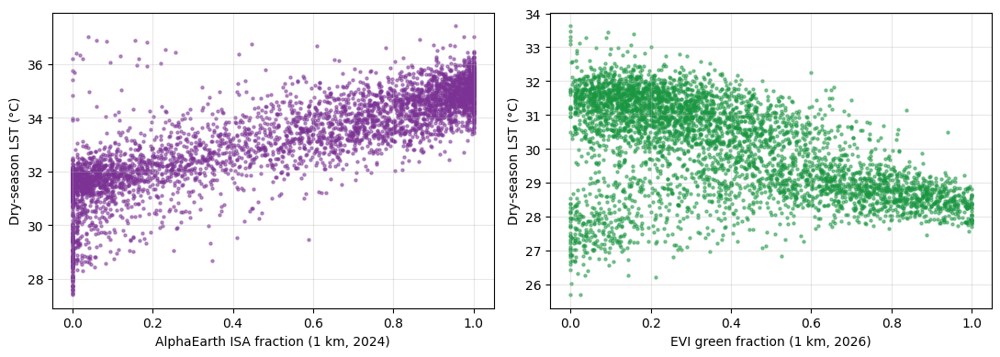

In [ ]:

MODIS = ee.ImageCollection('MODIS/061/MOD11A2')
# A composite (.mean()) has a default 1-degree WGS84 projection, so take the native sinusoidal ~927 m grid explicitly
MODIS_PROJ  = MODIS.first().select('LST_Day_1km').projection()
MODIS_SCALE = MODIS_PROJ.nominalScale().getInfo()
print(f'MODIS native scale: {MODIS_SCALE:.1f} m')

def modis_dry_lst(year, region):
    def qc(img):
        q = img.select('QC_Day')
        mand, err = q.bitwiseAnd(3), q.rightShift(6).bitwiseAnd(3)
        ok = mand.eq(0).Or(mand.eq(1).And(err.lte(1)))
        return img.select('LST_Day_1km').updateMask(ok).multiply(0.02).subtract(273.15)
    col = MODIS.filterDate(f'{year - 1}-12-01', f'{year}-05-01').filterBounds(region)
    print(f'  MOD11A2 composites {year - 1}-12 .. {year}-04: {col.size().getInfo()}')
    return col.map(qc).mean().rename('LST').setDefaultProjection(MODIS_PROJ)

# 'User memory limit exceeded' fix (1): build the 1 km fractions from a 100 m version of each class map
# (~86 samples per MODIS pixel instead of ~950 at 30 m). The RF classification of AlphaEarth is the heavy part,
# and at 100 m it runs on ~11x fewer pixels. Nearest-neighbour sampling keeps the 1 km fraction unbiased.
FRAC_SCALE = 100

def to_modis_grid(img):
    return (img.unmask(0).reproject(crs='EPSG:32647', scale=FRAC_SCALE)
            .reduceResolution(ee.Reducer.mean(), maxPixels=1024).reproject(MODIS_PROJ))

# 'User memory limit exceeded' fix (2): sample tile by tile (25 km tiles, ~700 MODIS pixels each)
# so every interactive request stays small and well under the 5,000-feature getInfo cap.
TILES = region_lst.coveringGrid(ee.Projection('EPSG:32647').atScale(25000))
N_TILES = TILES.size().getInfo()
TILE_LIST = TILES.toList(N_TILES)
print(f'sampling in {N_TILES} tiles of 25 km')

def sample_tiled(img):
    rows, failed = [], []
    for k in range(N_TILES):
        g = ee.Feature(TILE_LIST.get(k)).geometry().intersection(region_lst, ee.ErrorMargin(100))
        for ts in (16, 16):                                  # one retry on a transient failure
            try:
                fc = img.sample(region=g, projection=MODIS_PROJ, scale=MODIS_SCALE, geometries=False, tileScale=ts)
                rows += [f['properties'] for f in fc.getInfo()['features']]
                break
            except Exception as e:
                err = str(e)
        else:
            failed.append(k); print(f'  tile {k} failed: {err[:80]}')
    if failed:
        print(f'  ⚠️ {len(failed)} / {N_TILES} tiles failed — results cover only part of the region')
    return pd.DataFrame(rows)

def lst_isa_table(year, frac_imgs):
    lst = modis_dry_lst(year, region_lst)
    stk = lst.addBands([to_modis_grid(im).rename(n) for n, im in frac_imgs.items()])
    df = sample_tiled(stk).dropna()
    print(f'  {year}: {len(df)} MODIS pixels with valid LST')
    return df

def suhi(df, col):
    u, r = df[df[col] >= 0.5].LST, df[df[col] <= 0.1].LST
    out = {'isa_col': col, 'n_urban': int(len(u)), 'n_rural': int(len(r)), 'LST_urban': u.mean(), 'LST_rural': r.mean(),
           'SUHI': u.mean() - r.mean() if len(u) and len(r) else float('nan'),
           'pearson_r': stats.pearsonr(df[col], df.LST)[0], 'slope_C_per_10pp': stats.linregress(df[col], df.LST).slope / 10}
    if len(r) < 30:
        print(f'  ⚠️ only {len(r)} rural reference pixels for {col} — SUHI is unstable')
    return out

# (a) AlphaEarth ISA with LST of the same year
T_ae = lst_isa_table(AE_YEAR, {'isa_ae': isa_ae})
# (b) EVI 3-class for 2026 with LST of the 2026 dry season (S2 composite over the buffered region)
s2L, _ = make_s2(S2_START, S2_END, region=region_lst); s2Li = add_indices(s2L)
clsL = classify(s2Li, 0.3, 'NDWI', 0.1, region=region_lst)
T_evi = lst_isa_table(2026, {'imp': clsL.eq(2), 'green': clsL.eq(1), 'water': clsL.eq(3)})

suhi_tab = pd.DataFrame([{'year': AE_YEAR, **suhi(T_ae, 'isa_ae')}, {'year': 2026, **suhi(T_evi, 'imp')}])
display(suhi_tab.round(2))
rg = stats.pearsonr(T_evi.green, T_evi.LST)
ols = np.linalg.lstsq(np.c_[np.ones(len(T_evi)), T_evi.imp, T_evi.water], T_evi.LST, rcond=None)[0]
print(f'2026: r(LST, green fraction) = {rg[0]:.3f} | LST = {ols[0]:.2f} + {ols[1]:.2f}·imp + {ols[2]:.2f}·water  (green is the reference)')
RESULTS['suhi'] = suhi_tab.to_dict(orient='records')
RESULTS['lst_green_r_2026'] = float(rg[0]); RESULTS['lst_ols_2026'] = {'intercept': ols[0], 'imp': ols[1], 'water': ols[2]}

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].scatter(T_ae.isa_ae, T_ae.LST, s=5, alpha=.5, c='#7b3294'); axs[0].set_xlabel(f'AlphaEarth ISA fraction (1 km, {AE_YEAR})')
axs[1].scatter(T_evi.green, T_evi.LST, s=5, alpha=.5, c='#1a9641'); axs[1].set_xlabel('EVI green fraction (1 km, 2026)')
for ax in axs: ax.set_ylabel('Dry-season LST (°C)'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('fig_lst_scatter.png', dpi=160); plt.show()


**อ่านผลส่วน 14:**
- **2024 (AlphaEarth ISA):** SUHI = **3.19 °C** (เมือง 34.38 °C, n = 2,335 · ชนบท 31.19 °C, n = 1,127), r = 0.84, ความชัน **0.39 °C ต่อดาดแข็ง +10 จุด%**
  — ต่ำกว่า 4.01 °C ที่บทความรายงาน เพราะพื้นที่อ้างอิงต่างกัน (กทม. + บัฟเฟอร์ 10 กม. เทียบกับกรอบ 60×60 กม.) จึงเทียบได้เชิงทิศทางเท่านั้น
- **2026 (EVI 3 คลาส):** SUHI = 2.18 °C แต่มีพิกเซลชนบทเพียง **227** พิกเซล เพราะวิธี EVI นับนาหลังเก็บเกี่ยวเป็นดาดแข็ง พิกเซลที่เหลือเป็น "ชนบท" จึงเป็นพื้นที่ที่ยังเขียวหรือมีน้ำ → ค่านี้ไม่เสถียร
- พืชสัมพันธ์กับความเย็น: r(LST, สัดส่วนเขียว) = −0.48 · เมื่อเทียบกับพิกเซลเขียวล้วน ดาดแข็งล้วนร้อนกว่า ~3.2 °C และน้ำเย็นกว่า ~3.9 °C
- ⚠️ LST สัมบูรณ์ปี 2026 ต่ำกว่าปี 2024 ราว 4 °C ทั้งเมืองและชนบท — เป็นความต่างของสภาพอากาศรายปี **ห้ามเทียบค่าสัมบูรณ์ข้ามปี** เทียบได้เฉพาะ SUHI/ความชันภายในปีเดียวกัน
- ความชัน 0.39 °C/10 จุด% ต่ำกว่า 0.73 จากการวิเคราะห์ซ้ำข้อมูลบทความ (ส่วน 15) เพราะใช้ตัวแทน ISA และชุดพิกเซลต่างกัน — ขนาดผลขึ้นกับวิธี แต่ทิศทางตรงกัน

---
# 15) วิเคราะห์ซ้ำข้อมูลเปิดของบทความ — กรุงเทพฯ (รันได้โดยไม่ต้องใช้ GEE)

ดึงตารางผลจาก GitHub ของบทความ (`SitthisakMoukomla/tropical-urban-AlphaEarth`, MIT license) แล้ววิเคราะห์เฉพาะกรุงเทพฯ:
1. จุดตัวอย่าง MODIS LST × สัดส่วน built ของ Dynamic World (บัฟเฟอร์ 500 ม.) ปี 2024 — ความชันของ LST ต่อ ISA
2. อนุกรมเวลา 2017–2024 ของ LST เมือง/ชนบท และ SUHI — **ทดสอบแนวโน้มด้วย regression ไม่ใช่แค่เทียบปีต้น–ปลาย**
3. ผล repeated holdout ของ 3 วิธี (AlphaEarth / S2 annual 15 features / S2 best single-date 5 indices)

In [ ]:
REPO = os.path.join(WORKDIR, 'tropical-urban-AlphaEarth')
if not os.path.exists(REPO):
    subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/SitthisakMoukomla/tropical-urban-AlphaEarth.git', REPO], check=True)
DATA = os.path.join(REPO, 'data')

mp = pd.read_csv(os.path.join(DATA, 'GEE_mixed_pixel_LST_samples_DWproxy_2024.csv'))
b = mp[mp.City == 'Bangkok'].copy()
lr = stats.linregress(b.ISA_fraction, b.LST_C); ts = stats.theilslopes(b.LST_C, b.ISA_fraction)
hi, lo = b[b.ISA_fraction > 0.7].LST_C, b[b.ISA_fraction < 0.3].LST_C
print(f'n = {len(b)} 1-km pixels: {b.Pixel_Class.value_counts().to_dict()}')
print(f'OLS: LST = {lr.intercept:.2f} + {lr.slope:.2f}·ISA  → {lr.slope/10:.2f} °C per +10 pp ISA (SE {lr.stderr/10:.3f}), r = {lr.rvalue:.3f}, p = {lr.pvalue:.1e}')
print(f'Theil–Sen slope: {ts[0]/10:.2f} °C per +10 pp (95% CI {ts[2]/10:.2f}–{ts[3]/10:.2f})')
print(f'high-ISA (>0.7) minus low-ISA (<0.3): {hi.mean() - lo.mean():.2f} °C (n = {len(hi)}/{len(lo)})')
b['ISA_bin'] = pd.cut(b.ISA_fraction, np.arange(0, 0.9, 0.1))
display(b.groupby('ISA_bin', observed=True).LST_C.agg(['count', 'mean', 'std']).round(2))
RESULTS['paper_reanalysis_lst_isa_2024'] = {'n': int(len(b)), 'ols_slope_C_per_10pp': lr.slope / 10, 'ols_se_per_10pp': lr.stderr / 10,
    'r': lr.rvalue, 'theil_sen_per_10pp': ts[0] / 10, 'theil_sen_ci': [ts[2] / 10, ts[3] / 10],
    'high_minus_low_C': hi.mean() - lo.mean(), 'intercept_C': lr.intercept}

n = 338 1-km pixels: {'mixed_30_70': 248, 'low_ISA_pure_lt30': 72, 'high_ISA_pure_gt70': 18}
OLS: LST = 29.61 + 7.27·ISA  → 0.73 °C per +10 pp ISA (SE 0.027), r = 0.825, p = 2.8e-85
Theil–Sen slope: 0.71 °C per +10 pp (95% CI 0.65–0.77)
high-ISA (>0.7) minus low-ISA (<0.3): 4.00 °C (n = 18/72)


,count,mean,std
ISA_bin,,,
"(0.0, 0.1]",26,29.52,1.09
"(0.1, 0.2]",19,31.06,1.10
"(0.2, 0.3]",27,31.77,1.35
"(0.3, 0.4]",29,32.00,1.13
"(0.4, 0.5]",46,33.11,1.02
"(0.5, 0.6]",67,33.81,0.93
"(0.6, 0.7]",106,34.22,0.79
"(0.7, 0.8]",18,34.77,0.72


,Year,ISA_pct,LST_urban_C,LST_rural_C,SUHI_C,Pearson_r
0,2017,57.7,34.5,30.1,4.33,0.839
1,2018,55.9,34.1,30.0,4.11,0.826
2,2019,59.3,34.9,31.3,3.55,0.788
3,2020,61.8,34.5,30.9,3.60,0.800
4,2021,61.8,34.2,30.2,4.07,0.841
5,2022,62.9,34.7,30.2,4.50,0.848
6,2023,64.7,34.0,29.7,4.37,0.818
7,2024,65.1,33.9,30.3,3.55,0.812


ISA_pct      slope +1.269/yr (95% CI +0.851 to +1.687), p = 0.000; 2017→2024 endpoint change +7.40
LST_urban_C  slope -0.067/yr (95% CI -0.195 to +0.062), p = 0.251; 2017→2024 endpoint change -0.60
LST_rural_C  slope -0.049/yr (95% CI -0.253 to +0.156), p = 0.580; 2017→2024 endpoint change +0.20
SUHI_C       slope -0.010/yr (95% CI -0.170 to +0.150), p = 0.883; 2017→2024 endpoint change -0.78


,Method,SplitType,IoU_mean,IoU_ci_low,IoU_ci_high,F1_mean,OA_mean,n_features
0,AlphaEarth_RF_64D,random_stratified_holdout,0.886,0.880,0.893,0.940,0.934,64
1,AlphaEarth_RF_64D,spatial_block_holdout_0p05deg,0.885,0.877,0.893,0.939,0.933,64
10,S2_annual_fullbands_indices_RF,random_stratified_holdout,0.786,0.778,0.795,0.880,0.867,15
11,S2_annual_fullbands_indices_RF,spatial_block_holdout_0p05deg,0.787,0.779,0.795,0.881,0.867,15
20,S2_best_single_5indices_RF,random_stratified_holdout,0.733,0.725,0.741,0.846,0.828,5
21,S2_best_single_5indices_RF,spatial_block_holdout_0p05deg,0.732,0.721,0.742,0.845,0.827,5


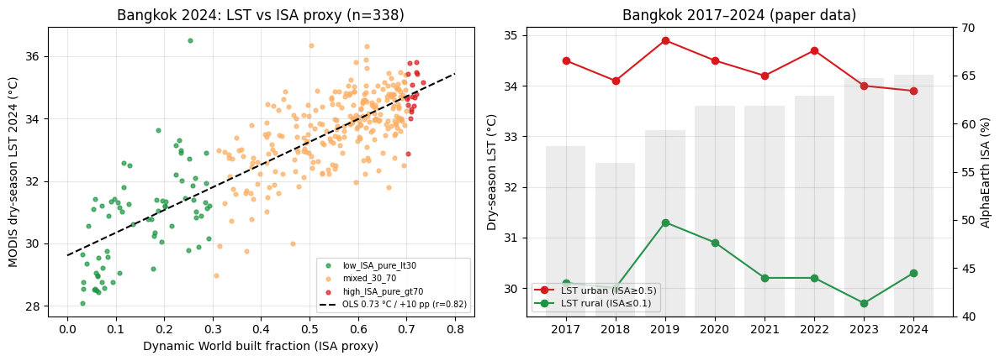

In [ ]:
c = pd.read_csv(os.path.join(DATA, 'LST_ISA_correlations_with_95CI.csv'))
cb = c[(c.City == 'Bangkok') & (c.Year <= 2024)].copy()           # 2025 is provisional in the paper
display(cb[['Year', 'ISA_pct', 'LST_urban_C', 'LST_rural_C', 'SUHI_C', 'Pearson_r']])
trend = {}
for col in ['ISA_pct', 'LST_urban_C', 'LST_rural_C', 'SUHI_C']:
    l = stats.linregress(cb.Year, cb[col]); t_ = stats.t.ppf(0.975, len(cb) - 2)
    trend[col] = {'slope_per_yr': l.slope, 'ci95': [l.slope - t_ * l.stderr, l.slope + t_ * l.stderr], 'p': l.pvalue,
                  'endpoint_change': float(cb[col].iloc[-1] - cb[col].iloc[0])}
    print(f'{col:12s} slope {l.slope:+.3f}/yr (95% CI {trend[col]["ci95"][0]:+.3f} to {trend[col]["ci95"][1]:+.3f}), p = {l.pvalue:.3f}; '
          f'2017→2024 endpoint change {trend[col]["endpoint_change"]:+.2f}')
RESULTS['paper_reanalysis_trends_bkk'] = trend

rb = pd.read_csv(os.path.join(DATA, 'GEE_sampled_repeated_seed_summary.csv'))
rbb = rb[rb.City == 'Bangkok'][['Method', 'SplitType', 'IoU_mean', 'IoU_ci_low', 'IoU_ci_high', 'F1_mean', 'OA_mean', 'n_features']]
display(rbb.round(3))
RESULTS['paper_reanalysis_holdout_bkk'] = rbb.to_dict(orient='records')

fig, axs = plt.subplots(1, 2, figsize=(12, 4.4))
colors = {'low_ISA_pure_lt30': '#1a9641', 'mixed_30_70': '#fdae61', 'high_ISA_pure_gt70': '#d7191c'}
for k, v in colors.items():
    q = b[b.Pixel_Class == k]; axs[0].scatter(q.ISA_fraction, q.LST_C, s=12, c=v, label=k, alpha=.7)
xx = np.linspace(0, .8, 10); axs[0].plot(xx, lr.intercept + lr.slope * xx, 'k--', label=f'OLS {lr.slope/10:.2f} °C / +10 pp (r={lr.rvalue:.2f})')
axs[0].set_xlabel('Dynamic World built fraction (ISA proxy)'); axs[0].set_ylabel('MODIS dry-season LST 2024 (°C)')
axs[0].legend(fontsize=7); axs[0].grid(alpha=.3); axs[0].set_title(f'Bangkok 2024: LST vs ISA proxy (n={len(b)})')
axs[1].plot(cb.Year, cb.LST_urban_C, 'o-', c='#d7191c', label='LST urban (ISA≥0.5)')
axs[1].plot(cb.Year, cb.LST_rural_C, 'o-', c='#1a9641', label='LST rural (ISA≤0.1)')
ax2 = axs[1].twinx(); ax2.bar(cb.Year, cb.ISA_pct, alpha=.15, color='gray'); ax2.set_ylabel('AlphaEarth ISA (%)'); ax2.set_ylim(40, 70)
axs[1].set_ylabel('Dry-season LST (°C)'); axs[1].set_title('Bangkok 2017–2024 (paper data)'); axs[1].legend(fontsize=8, loc='lower left'); axs[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig('fig_paper_reanalysis.png', dpi=160); plt.show()

**ข้อสังเกตเชิงวิพากษ์ (จากตัวเลขด้านบน):** บทความเขียนว่า SUHI ของทุกเมือง "ลดลง" ช่วง 2017–2024 (กรุงเทพฯ −0.78 °C) โดยอธิบายว่าชนบทร้อนขึ้นเร็วกว่าเมือง
แต่ตัวเลข −0.78 °C มาจาก **การลบปีปลายด้วยปีต้น** — เมื่อทดสอบแนวโน้มด้วย regression ทั้ง 8 ปี ความชันของ SUHI กรุงเทพฯ ≈ 0 และช่วงเชื่อมั่นคร่อมศูนย์
และ LST ชนบทก็ **ไม่ได้มีแนวโน้มเพิ่มขึ้นอย่างมีนัยสำคัญ** → สำหรับกรุงเทพฯ ข้อมูลของบทความเองยังไม่พอสนับสนุนทั้ง "SUHI ลดลง" และคำอธิบาย "ชนบทร้อนขึ้น"
(ตารางของบทความก็รายงาน Kendall p = 0.90 สำหรับ SUHI กรุงเทพฯ ไว้แล้ว — สิ่งที่ขัดกันคือข้อความในส่วนอภิปราย)

---
# 16) Export ผลทั้งหมด (สำหรับรายงาน)

In [ ]:
def _clean(o):
    if isinstance(o, dict): return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [_clean(v) for v in o]
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.bool_,)): return bool(o)
    return o
with open('lab4_results.json', 'w', encoding='utf-8') as f:
    json.dump(_clean(RESULTS), f, ensure_ascii=False, indent=1)

lines = ['# Lab 4 — auto-generated results summary', '']
if 'main_evi0.3' in RESULTS:
    m = RESULTS['main_evi0.3']
    lines += [f"- Bangkok, S2 {S2_START}–{S2_END}, EVI≥0.3: green {m['green_pct']:.1f}% ({m['green_km2']:.1f} km²), "
              f"impervious {m['imperv_pct']:.1f}%, water {m['water_pct']:.1f}%, no-data {m['nodata_pct']:.2f}%",
              f"- Green per capita: {m['green_m2_per_capita']:.1f} m² (registered) / {m['green_m2_per_capita_resident']:.1f} m² (resident 10.5 M)"]
if 'sensitivity_swing' in RESULTS:
    s = RESULTS['sensitivity_swing']
    lines += [f"- Sensitivity 0.2–0.4: green per capita {s['green_pc_min']:.1f}–{s['green_pc_max']:.1f} m² (×{s['ratio_max_over_min']:.2f}); green share range {s['green_pct_range_pp']:.1f} pp"]
if 'gba_totals' in RESULTS:
    g = RESULTS['gba_totals']
    lines += [f"- GBA: {g['n_buildings']:,} buildings, footprint {g['footprint_km2']:.1f} km² → building coverage {g['bcr_pct']:.1f}% of Bangkok"]
for k in ['green_definitions', 'agreement_vs_dynamic_world', 'imperv_share_by_method', 'grid1km_validation', 'suhi',
          'district_ring_green', 'paper_reanalysis_lst_isa_2024', 'paper_reanalysis_trends_bkk']:
    if k in RESULTS:
        lines += ['', f'## {k}', '```', json.dumps(_clean(RESULTS[k]), ensure_ascii=False, indent=1)[:3000], '```']
open('lab4_results_summary.md', 'w', encoding='utf-8').write('\n'.join(lines))
print('\n'.join(lines[:12]))
print('\nfiles:', [f for f in os.listdir('.') if f.startswith(('lab4_', 'fig_'))])

# Lab 4 — auto-generated results summary

- Bangkok, S2 2026-01-01–2026-04-30, EVI≥0.3: green 37.4% (587.3 km²), impervious 58.3%, water 3.9%, no-data 0.03%
- Green per capita: 107.7 m² (registered) / 55.9 m² (resident 10.5 M)
- Sensitivity 0.2–0.4: green per capita 67.6–151.6 m² (×2.24); green share range 29.2 pp
- GBA: 2,192,944 buildings, footprint 326.1 km² → building coverage 20.8% of Bangkok

## green_definitions
```
[
 {
  "definition": "G0: EVI >= 0.3 (class definition)",
  "green_km2": 587.3484501518235,
  "green_pct": 37.37040666972705,
  "m2_per_capita_registered": 107.65184203662454,
  "m2_per_capita_resident": 55.937947633507
 },
 {
  "definition": "G1: G0 minus WorldCover cropland",
  "green_km2": 424.3724443435151,
  "green_pct": 27.000957984044888,
  "m2_per_capita_registered": 77.7808732301164,
  "m2_per_capita_resident": 40.41642327081096
 },
 {
  "definition": "G2: G0 within WorldCover tree cover",
  "green_km2": 238.42426026289792,
  "green_pct": 15.169890315791578,

---
# คำถามท้ายบทปฏิบัติการ

1. จากตาราง sensitivity — ตัวเลข "พื้นที่เขียวต่อหัว" แกว่งแค่ไหนเมื่อขยับ threshold? ถ้าต้องรายงานตัวเลขเดียวต่อสาธารณะ จะเลือกค่าไหนและจะเขียนหมายเหตุกำกับว่าอย่างไร
2. วิธีนี้นับ "สนามหญ้าในบ้านจัดสรร" กับ "นาข้าวชานเมือง" เป็นพื้นที่เขียวด้วย — สิ่งนี้ทำให้ตัวชี้วัด "เขียวต่อหัว" สูงเกินความหมายเชิงนโยบายอย่างไร และจะนิยาม "พื้นที่เขียวที่ประชาชนเข้าถึงได้จริง" ให้วัดได้ด้วยข้อมูลอะไรเพิ่ม
3. ถ้าเป็นนายกเทศมนตรีของเมืองที่เลือก จะเพิ่มพื้นที่เขียวที่โซนไหนก่อน — ตอบโดยชี้จากแผนที่ (แคปหน้าจอประกอบ) พร้อมเหตุผล 3-4 บรรทัด

*ส่ง: ลิงก์ Colab + ตาราง sensitivity + คำตอบ 3 ข้อ ใน Google Classroom*

เซลล์ถัดไปพิมพ์ตัวเลขที่ใช้ตอบจากผลรันจริง (ห้ามพิมพ์ตัวเลขเองในคำตอบ — คัดลอกจาก output)

In [ ]:
def _g(path, default='[ยังไม่ได้รัน]'):
    cur = RESULTS
    for p in path:
        if isinstance(cur, dict) and p in cur: cur = cur[p]
        else: return default
    return cur
s = _g(['sensitivity_swing'])
if isinstance(s, dict):
    print(f"Q1: green per capita ranges {s['green_pc_min']:.1f}–{s['green_pc_max']:.1f} m²/person over EVI 0.2–0.4 "
          f"(max/min = {s['ratio_max_over_min']:.2f}); green share shifts by {s['green_pct_range_pp']:.1f} pp.")
gd_ = _g(['green_definitions'])
if isinstance(gd_, list):
    for r in gd_: print(f"Q2: {r['definition']:18s} {r['m2_per_capita_registered']:8.1f} m²/registered person | {r['m2_per_capita_resident']:8.1f} m²/resident")
if 'district_ring_green' in RESULTS:
    for r in RESULTS['district_ring_green']: print(f"Q3: {r['ring']:18s} green {r['green_m2_pc']:7.1f} m²/p | tree {r['tree_m2_pc']:6.1f} m²/p")
if 'gba_rings' in RESULTS:
    for r in RESULTS['gba_rings']: print(f"Q3 (GBA): {r['ring']:18s} BCR {r['bcr_pct']:5.1f}% | non-building land {r['nonbuilt_m2_pc']:6.1f} m²/p | density {r['density_km2']:,.0f}/km²")

Q1: green per capita ranges 67.6–151.6 m²/person over EVI 0.2–0.4 (max/min = 2.24); green share shifts by 29.2 pp.
Q2: G0: EVI >= 0.3 (class definition)    107.7 m²/registered person |     55.9 m²/resident
Q2: G1: G0 minus WorldCover cropland     77.8 m²/registered person |     40.4 m²/resident
Q2: G2: G0 within WorldCover tree cover     43.7 m²/registered person |     22.7 m²/resident
Q3: Inner (<8 km)      green    21.0 m²/p | tree   12.1 m²/p
Q3: Middle (8-16 km)   green    50.8 m²/p | tree   26.4 m²/p
Q3: Outer (>16 km)     green   211.7 m²/p | tree   74.6 m²/p
Q3 (GBA): Inner (<8 km)      BCR  33.9% | non-building land   74.1 m²/p | density 8,925/km²
Q3 (GBA): Middle (8-16 km)   BCR  27.1% | non-building land  149.7 m²/p | density 4,868/km²
Q3 (GBA): Outer (>16 km)     BCR  15.5% | non-building land  399.7 m²/p | density 2,114/km²


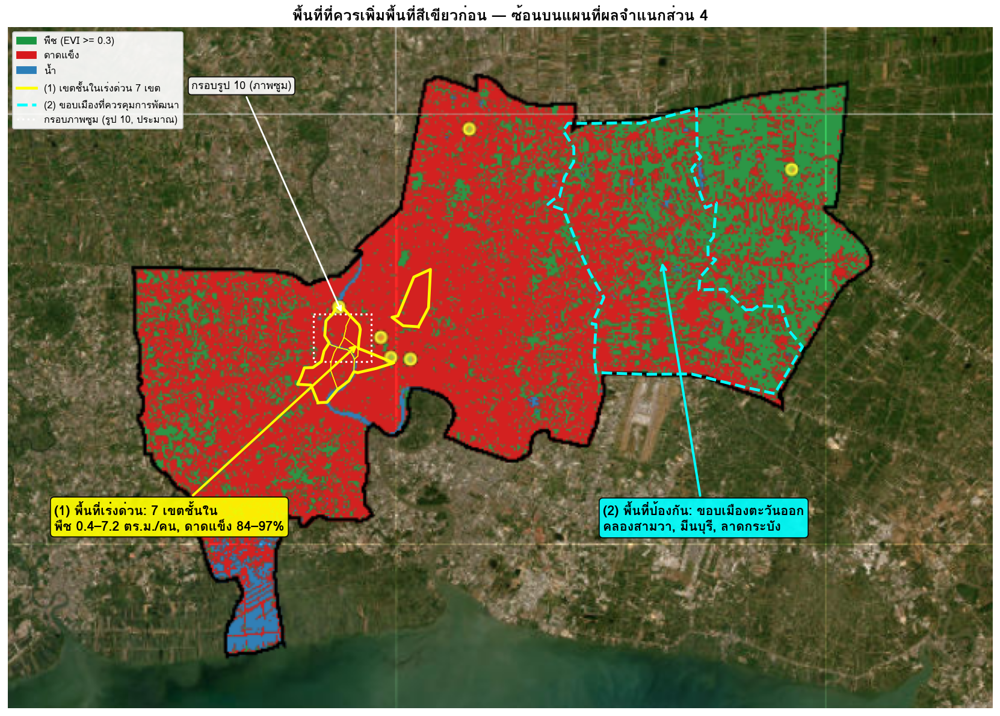


### คำตอบข้อ 1 — ความไวของ "เขียวต่อหัว" และตัวเลขที่ควรรายงาน

เมื่อขยับเกณฑ์ EVI จาก 0.2 → 0.4 พื้นที่สีเขียวของกรุงเทพฯ ลดจาก **52.6% → 23.5%** (แกว่ง 29.2 จุด%) และเขียวต่อหัวลดจาก **151.6 → 67.6 ตร.ม./คน — ต่างกัน 2.24 เท่า**
ทั้งที่ภาพ เมือง และประชากรเหมือนเดิมทุกอย่าง ทุกเกณฑ์ "ผ่าน WHO ~9 ตร.ม./คน" แม้หารด้วยประชากรอาศัยจริง 10.5 ล้านคน (ต่ำสุด ≈ 35 ตร.ม./คน)
— การผ่านแบบนี้ไม่มีความหมายเชิงนโยบาย เพราะนิยามนับพืชทุกชนิดรวมนาข้าวในเขตชั้นนอก

**ถ้าต้องรายงานตัวเลขเดียว:** ใช้ EVI ≥ 0.3 (ค่ากลางของช่วงที่ทดสอบ) พร้อมหมายเหตุบังคับ:

> *"พื้นที่ปกคลุมด้วยพืชของกรุงเทพฯ ≈ 108 ตร.ม./คน (Sentinel-2 หน้าแล้ง ม.ค.–เม.ย. 2569, EVI ≥ 0.3, 10 ม., ประชากรทะเบียนราษฎร์ ธ.ค. 2567)
> ช่วงจากการเลือกเกณฑ์ 0.2–0.4 = 68–152 ตร.ม./คน · รวมนาข้าวและสนามหญ้าเอกชน ไม่ใช่พื้นที่สีเขียวสาธารณะ
> · ถ้าใช้ประชากรอาศัยจริง ~10.5 ล้านคน = ≈ 56 ตร.ม./คน"*

ข้อควรระวังที่จุดตรวจเผยให้เห็น: พิกเซลสนามหญ้าในสวนลุมพินีมี EVI หน้าแล้ง 0.288 จึงตกเกณฑ์ 0.3 (แม้ในรัศมี 150 ม. ยังเป็นเขียว 62%) — เกณฑ์เดียวกันนับนาข้าวชานเมืองเป็นเขียว แต่ตัดสนามหญ้าบางส่วนในสวนกลางเมืองทิ้ง

*หมายเหตุ:* ตัวเลข "9 ตร.ม./คน ของ WHO" ถูกอ้างต่อกันแพร่หลาย (รวมถึงในเอกสารประกอบการสอน) แต่ผู้จัดทำยังไม่พบในเอกสารทางการของ WHO — ข้อแนะนำของ WHO Europe (2016) เน้น **การเข้าถึงพื้นที่สีเขียวในระยะ ~300 ม.** มากกว่าค่า ตร.ม./คน จึงใช้ 9 ตร.ม./คน เป็นเพียงค่าอ้างอิงตามคาบ

### คำตอบข้อ 2 — ทำไม "เขียวต่อหัว" สูงเกินความหมายเชิงนโยบาย และจะวัดพื้นที่เขียวที่เข้าถึงได้อย่างไร

1. **นับสิ่งที่ประชาชนใช้ไม่ได้:** หนองจอกมีพืช 1,050.7 ตร.ม./คน แต่เมื่อตัด cropland ของ WorldCover ออกเหลือ 467.7 (−55%) และเหลือเฉพาะเรือนยอดไม้ 285.2 —
   พืชส่วนใหญ่ของเขตชั้นนอกคือนาและไร่ · ระดับทั้งเมือง: G0 (EVI ≥ 0.3) = **107.7** → G1 ตัดนาออก = **77.8** → G2 เฉพาะเรือนยอดไม้ = **43.7 ตร.ม./คน**
   (หารประชากรอาศัยจริง: 55.9 → 40.4 → 22.7) — "พื้นที่เขียว" ตามนิยามของคาบ มีเรือนยอดไม้เพียง 40.6% นา 27.7% และพิกเซลที่ WorldCover ระบุว่าเป็นสิ่งปลูกสร้างถึง 16.0%
2. **ค่าเฉลี่ยซ่อนความเหลื่อมล้ำ:** เขตชั้นในมีพืช **21.0 ตร.ม./คน** (เรือนยอดไม้ 12.1) เทียบกับชั้นนอก **211.7** (74.6) — ต่างกันเกือบ 10 เท่า;
   Gini ถ่วงประชากรของเขียวต่อหัวระหว่างเขต = **0.64**; **16 จาก 50 เขต** มีเรือนยอดไม้ต่ำกว่า 9 ตร.ม./คน
3. **ตัวหารผิด:** ทะเบียนราษฎร์ (~5.46 ล้าน) ต่ำกว่าประชากรที่ใช้เมืองจริงมาก → ตัวเลขต่อหัวสูงเกิน ~2 เท่า
4. **หน้าแล้งทำให้นาหลังเก็บเกี่ยวกลายเป็น "ดาดแข็ง"** — ความคลาดเคลื่อนเกิดทั้งสองทาง

**นิยามที่วัดได้:** *พื้นที่สีเขียวสาธารณะที่เข้าถึงได้* = (ก) พื้นที่สาธารณะ — ขอบเขตสวนของ กทม. และ OSM `leisure=park`
(ข) มีพืชจริง — เรือนยอดไม้/EVI ตัดลานคอนกรีตในสวนออก (ค) ในระยะเดิน 300–500 ม. บนโครงข่ายถนน
แล้วหารด้วยประชากรเชิงพื้นที่ (WorldPop/GHS-POP 100 ม.) รายงานเป็น "% ประชากรที่อยู่ภายใน 500 ม. จากสวน" คู่กับ ตร.ม./คน — แนวเดียวกับ SDG 11.7.1

### คำตอบข้อ 3 — ถ้าเป็นผู้ว่าฯ กทม. จะเพิ่มพื้นที่เขียวที่ไหนก่อน



**ลำดับแรก: เขตชั้นในที่ทั้งไม่มีพืชและไม่มีที่ว่าง** — สัมพันธวงศ์ (พืช **0.4 ตร.ม./คน**), ป้อมปราบศัตรูพ่าย (1.6), บางรัก (4.3), ดินแดง (4.9), พระนคร (6.2), คลองสาน (6.4) และธนบุรี (7.2)
ทั้ง 7 เขตต่ำกว่า 9 ตร.ม./คน **แม้ใช้นิยามที่ใจดีที่สุด** ดาดแข็ง 84–97% ของพื้นที่เขต และหลังคาอาคาร (GBA) 35–46% — ดินแดงเขตเดียวมีประชากรทะเบียน 130,000 คน
ที่ดินผืนใหญ่ไม่มี จึงต้องใช้ **ต้นไม้ริมทาง, pocket park บนที่ดินรัฐ, หลังคาเขียว, ลานจอดซึมน้ำ**
**ลำดับที่สอง (ป้องกัน): ขอบเมือง** — คลองสามวา มีนบุรี ลาดกระบัง (พืช 47–52% ของพื้นที่เขต โดย 25–42% ของพืชนั้นเป็นนาตาม WorldCover) LST หน้าแล้งเพิ่ม 0.4–0.7 °C ต่อดาดแข็ง +10 จุด% (ผลของเราเอง 0.39 จากส่วน 14 และ 0.73 จากข้อมูลบทความในส่วน 15) และ SUHI ปี 2024 ≈ 3.2 °C
กำหนดสัดส่วนพื้นที่ซึมน้ำขั้นต่ำในผังเมืองรวมก่อนเปลี่ยนเป็นคอนกรีต ถูกกว่าการซื้อคืนภายหลังมาก


---
# ข้อจำกัดและข้อความที่ยังไม่ได้พิสูจน์ (Limitations & unverified claims)

| # | ประเด็น | ผลต่อข้อสรุป |
|---|---|---|
| 1 | **เกณฑ์ EVI 0.3 และ NDWI 0.1 เป็นค่าที่เลือกเอง** ไม่ได้ปรับเทียบกับข้อมูลอ้างอิงของกรุงเทพฯ | % เขียว/ดาดแข็งเปลี่ยนตามเกณฑ์ (ข้อ 6) — ไม่มี "ค่าจริง" ค่าเดียว |
| 2 | **"ดาดแข็ง" = ทุกอย่างที่ไม่เขียวและไม่ใช่น้ำ** รวมดินเปิด นาหลังเก็บเกี่ยว ที่รกร้างแห้ง | overestimate ดาดแข็งในเขตเกษตรหน้าแล้ง (หนองจอก ลาดกระบัง บางขุนเทียน) |
| 3 | ไม่มีข้อมูลภาคสนาม (ground truth) — Dynamic World, WorldCover, GHSL เป็นผลิตภัณฑ์จากโมเดลทั้งหมด และหลายตัวใช้ Sentinel-2 เหมือนกัน | ค่า IoU/r เป็น "ความสอดคล้องระหว่างผลิตภัณฑ์" ไม่ใช่ความแม่นยำ |
| 4 | GBA เป็นขอบล่างของดาดแข็ง (ไม่มีถนน/ลานจอด) และเป็นการรวมหลายแหล่ง (Google 88% ของจำนวนอาคาร) ที่ไม่ระบุปีภาพที่ใช้ชัดเจน; อาคาร 53,446 หลังสูง < 1 ม. | ใช้ตรวจรูปแบบเชิงพื้นที่ ไม่ใช่ค่าสัมบูรณ์ของดาดแข็ง |
| 5 | ประชากรรายเขตเป็นข้อมูลทะเบียนราว 2560–61 ส่วนระดับจังหวัดเป็น ธ.ค. 2567; ทั้งคู่ไม่รวมประชากรแฝง | "ต่อหัว" สูงเกินจริง และปีไม่ตรงกับภาพ 2569 |
| 6 | ขอบเขต 3 ชุดไม่ตรงกัน (GAUL 2015 ใน GEE · geoBoundaries ที่ใช้ clip GBA · OpenGISData สำหรับเขต) — อาคาร 0.9% ตกนอก polygon เขต | ความคลาดเคลื่อนเล็กที่ขอบ |
| 7 | AlphaEarth RF ใช้ `minLeafPopulation` แทน `max_depth` (GEE ไม่มีพารามิเตอร์นี้), พื้นที่ขอบเขต กทม. แทนกรอบ 60×60 กม. | ตัวเลขเทียบกับบทความได้เชิงทิศทางเท่านั้น |
| 8 | SUHI ใช้ กทม. + บัฟเฟอร์ 10 กม. เป็นฐานชนบท (รวมพื้นที่จังหวัดข้างเคียง) และ MODIS 1 กม. มีพิกเซลผสม; ความคลาดเคลื่อนการวัด LST ~±1 K | ค่า SUHI ขึ้นกับการเลือกพื้นที่อ้างอิง |
| 9 | การรวมจาก 10 ม. เป็น 1 กม. ทำให้ค่า r สูงขึ้นเกินจริง (smoothing) — ข้อจำกัดเดียวกับที่บทความระบุ | r ที่ 1 กม. ≠ ความแม่นยำระดับพิกเซล |
| 10 | **ข้อความในบทความที่ยังไม่ได้รับการสนับสนุนสำหรับกรุงเทพฯ:** "SUHI ลดลง 2017–2024 เพราะชนบทร้อนขึ้น" — ความชันของ SUHI และ LST ชนบทไม่ต่างจากศูนย์ (ส่วน 15) | ไม่ควรอ้างต่อโดยไม่ทดสอบแนวโน้ม |
| 11 | จุดตรวจใช้พิกัดโดยประมาณ — พิกเซลเดียวตกบนบึง (เบญจกิติ) และสนามหญ้า (ดอนเมือง) ได้ | ใช้สัดส่วนในรัศมี 150 ม. + ตรวจภาพประกอบเสมอ |
| 12 | GHSL ใช้ epoch 2020 (100 ม.) เพราะไม่มีภาพ 2018 ในชุด 100 ม. — ปีไม่ตรงกับบทความ | เทียบเชิงรูปแบบเท่านั้น |
| 13 | สัดส่วนคลาสระดับ 1 กม. ในส่วน 14 ประมาณจากแผนที่ที่สุ่มใหม่ที่ 100 ม. (ไม่ใช่ 10 ม. เต็ม) | ค่าเฉลี่ยไม่เอนเอียงแต่แปรปรวนขึ้นเล็กน้อย |
| 14 | LST สัมบูรณ์ต่างกันมากระหว่างปี (2026 เย็นกว่า 2024 ~4 °C) และ SUHI 2026 มีพิกเซลชนบทเพียง 227 | เทียบเฉพาะภายในปี · SUHI 2026 ไม่เสถียร |

## บันทึกการแก้ไข (หลังรันรอบแรกบน Colab)

| ส่วน | อาการ | สาเหตุ | การแก้ |
|---|---|---|---|
| 0 | เซลล์ตั้งค่า GEE ซ้ำ 3 เซลล์ | คัดลอกซ้ำ | ลบเหลือเซลล์เดียว |
| 1 | DeprecationWarning ของ FAO/GAUL/2015 | Asset ถูกแทนที่ด้วย GAUL 2025 แต่ยังใช้งานได้ | คง 2015 ไว้ให้ตรงกับบทความ และกรองคำเตือน |
| 7 | ลุมพินี → ดาดแข็ง, เบญจกิติ → น้ำ, ดอนเมือง → เขียว | พิกเซลเดียวกับพิกัดประมาณ (ตกบนบึง/สนามหญ้า) และ EVI ลุมพินี 0.288 < 0.3 | เพิ่มสัดส่วนคลาสในรัศมี 150 ม. + แก้ป้ายคาดหวัง + บันทึกผล |
| 10 | `Image.rename: Invalid band name 'G0_EVI>=0.3'` | ชื่อแบนด์ EE ใช้ได้แค่ตัวอักษร ตัวเลข `_` | เปลี่ยนเป็น `G0_evi`, `G1_noncrop`, `G2_tree` (ส่วน 11 อัปเดตตาม) |
| 13 | `Image asset 'JRC/GHSL/P2023A/GHS_BUILT_S/2018' not found` | ชุด 100 ม. มีเฉพาะ epoch ทุก 5 ปี | ใช้ epoch 2020 พร้อม fallback ถ้าโหลดไม่ได้จะข้าม GHSL |
| 14 | `Image.sample: You must specify a scale…` | ส่ง `projection` โดยไม่ส่ง `scale` | ส่ง `scale=MODIS_SCALE` |
| 14 | (บั๊กแฝง) | `.mean()` ทำให้ภาพเสีย projection ของ MODIS (กลายเป็น 1° WGS84) → การรวมพิกเซลขึ้นกริดผิด | ใช้ projection ดั้งเดิมของ MOD11A2 + `setDefaultProjection` |
| 14 | (เสี่ยง) | กทม. + บัฟเฟอร์ 10 กม. ≈ 4,000–5,000 พิกเซล ใกล้เพดาน `getInfo` 5,000 | ดึงข้อมูลแบบแบ่งหน้า (`fc_to_df`) |
| 14 | `User memory limit exceeded` (รอบสอง) | จำแนก RF ของ AlphaEarth ทุกพิกเซล 30 ม. บนพื้นที่ ~4,000 ตร.กม. ในคำขอเดียว | คำนวณสัดส่วนจากแผนที่ 100 ม. + สุ่มตัวอย่างทีละไทล์ 25 กม. |
| 16, คำตอบ | ผลค้างจากรอบที่ส่วน 10/13/14 error | — | ล้าง output ให้รันใหม่ · เขียนคำตอบข้อ 1–3 ด้วยตัวเลขที่รันได้จริง |

## อ้างอิง
- Moukomla, S.; Meeprom, P.; Intarat, K. (2026). Impact of Impervious Surface Expansion on Urban Thermal Environment Across Tropical Southeast Asian Megacities. *Earth* 7, 76. doi:10.3390/earth7030076 · code/data: github.com/SitthisakMoukomla/tropical-urban-AlphaEarth
- Huete, A. et al. (2002). Overview of the radiometric and biophysical performance of the MODIS vegetation indices. *Remote Sens. Environ.* 83, 195–213. (EVI)
- McFeeters, S.K. (1996). The use of the NDWI in the delineation of open water features. *Int. J. Remote Sens.* 17, 1425–1432.
- Xu, H. (2006). Modification of NDWI to enhance open water features (MNDWI). *Int. J. Remote Sens.* 27, 3025–3033.
- Brown, C.F. et al. (2022). Dynamic World. *Sci. Data* 9, 251 · Brown, C.F. et al. (2025). AlphaEarth Foundations. arXiv:2507.22291
- Zanaga, D. et al. (2022). ESA WorldCover 10 m 2021 v200 · Pesaresi, M. et al. (2024). GHSL P2023A. *Int. J. Digit. Earth* 17
- Zhu, X.X. et al. (2025). GlobalBuildingAtlas (GBA LoD1), Source Cooperative `tge-labs/globalbuildingatlas-lod1`
- Wan, Z. (2014). MODIS LST collection-6. *Remote Sens. Environ.* 140, 36–45 · Imhoff, M.L. et al. (2010). *Remote Sens. Environ.* 114, 504–513
- กรมการปกครอง: สถิติประชากรทะเบียนราษฎร์ (ผ่าน Wikipedia: *Provinces of Thailand*, *List of districts of Bangkok*) · OpenGISData-Thailand (chingchai, GitHub)